## Exercise sheet 3: Laura Saiz, David Edel

In [90]:
# imports
# pyright: basic
import torch
import torch.nn as nn
from torch.amp import autocast, GradScaler  # pyright: ignore[reportPrivateImportUsage]
import matplotlib.pyplot as plt
# make moons dataset
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split


### Ex 1: Two moons with an invertible neural network

<div style="color: green; font-weight:bold">
Overall, differences in classes the way they are programmed but equivalent to the soloution. Training with different hyperparameters with plotted loss function over epochs instead of total loss and scatterplots. Overall more trying out. Hexagonal shape task equivalent.
</div>

In [91]:
# pyright: basic
# define RealNVP, and its building blocks
# device that is either cpu, cuda or mps
from typing import Optional

device = torch.device("cpu")
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

def to_onehot(y,num_classes:int = 2):
    return torch.nn.functional.one_hot(y, num_classes=num_classes)


def get_orthonormal_matrix(d:int) -> torch.Tensor:
    A = torch.randn((d,d))
    Q, _R = torch.linalg.qr(A)
    return Q.to(device)

class CouplingBlock(nn.Module):
    def __init__(self, input_size:int, hidden_size:int, condition_size:int = 0):
        super(CouplingBlock, self).__init__()
        self.scale_net = nn.Sequential(
            nn.Linear(input_size//2 + condition_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, input_size//2),
            nn.Tanh(),
    
            # remember to exp this
        )
        self.t_net = nn.Sequential(
            nn.Linear(input_size//2+condition_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, input_size//2)
        )
        self.block_det = 0
        

    def forward(self, x:torch.Tensor, y: torch.Tensor = torch.ones((0,),device=device)): # assume x is of shape (batch_size, input_size)
        x1,x2 = torch.split(x, x.size(1)//2, dim=1)  # creates views!
        x1_cond = torch.cat([x1,y],dim=1)
        scaled_x1 = self.scale_net(x1_cond)
        z2 = x2 * torch.exp(scaled_x1) + self.t_net(x1_cond) # could be exp(a * ...), but also for backwards.
        # where a is hyperparam
        z = torch.cat([x1, z2], dim=1)
        #if self.training: 
        # # just always compute, because we need it for loss calculation
        # its not necesarry for inference, but we only do training and testing 
        self.block_det = torch.sum(scaled_x1) 
        return z
        
    def reverse(self, z, y):
        z1,z2 = torch.split(z,z.size(1) // 2, dim=1)
        x1 = torch.cat([z1,y],dim=1)
        x2 = (z2 - self.t_net(x1)) / torch.exp(self.scale_net(x1))
        x = torch.cat([z1,x2],dim=1)
        return x

class RealNVP(nn.Module):
    condition_size: int
    def __init__(self,input_size:int, hidden_size:int, blocks:int, condition_size:int = 0):
        super(RealNVP, self).__init__()
        self.input_size = input_size
        self.condition_size = condition_size
        self.blocks:nn.ModuleList[CouplingBlock] = nn.ModuleList()
        self.rotation_matrices = []
        for i in range(blocks -1):
            self.blocks.append(CouplingBlock(input_size , hidden_size, condition_size))
            R = get_orthonormal_matrix(input_size) # R means Rotational matrix, 
            # could also be named Q.
            R.requires_grad = False # prof said its not worth to learn (probably)
            # but it seams to decrease train loss.
            self.rotation_matrices.append(R)

        #!TODO: readd
        self.blocks.append(CouplingBlock(input_size, hidden_size, condition_size))

    def forward(self, x, y=torch.ones((0,),device=device)):
        """
        y should be a onehot
        """
        for block, R in zip(self.blocks, self.rotation_matrices):  # pyright: ignore[reportAssignmentType]
            block:CouplingBlock
            # last from blocks will not be used in this loop
            x = block.forward(x, y)
            x = x @ R  # rotation # TODO: BATCH support
        #!TODO: readd
        x = self.blocks[-1].forward(x, y)
        return x
    def reverse(self, z:torch.Tensor, y:torch.Tensor = torch.ones((0,))):
        #!TODO: readd
        #x = z
        x = self.blocks[-1].reverse(z, y)  # pyright: ignore[reportCallIssue]
        for block, R in zip(reversed( self.blocks[:-1]),reversed(self.rotation_matrices)):  # pyright: ignore[reportAssignmentType]
            block:CouplingBlock
            x = x @ R.T # TODO: batch
            x = block.reverse(x, y)
        return x

    def sample(self,num_samples:int, conditions: Optional[torch.Tensor] = None ):
        effective_num_samples = num_samples if conditions is None else num_samples * conditions.size(0)
        gaussians = torch.randn(effective_num_samples, self.input_size,device=device)
        if conditions is not None: # conditions is provided
            conditions =torch.nn.functional.one_hot(conditions.long(), num_classes=self.condition_size)
            conditions = conditions.repeat(num_samples, 1)
        else: # conditions is not provided
            if self.condition_size == 0: # stack empty tensor
                conditions = torch.ones((num_samples,0),device=device)
            else: # is a conditional model, but no classes were supplied, so draw random
                conditions = torch.randint(0, self.condition_size, (num_samples,),device=device)
                conditions =torch.nn.functional.one_hot(conditions.long(), num_classes=self.condition_size)
        return self.reverse(gaussians, conditions)
        

In [92]:
# pyright: basic

def calculate_loss(model, output):
    loss = 0
    for block in model.blocks:
        block:CouplingBlock
        loss -= block.block_det
    loss+= output.pow(2).sum() / 2 # sum over all axis
    return loss / output.size(0)  # mean over batch


from lion_pytorch import Lion
def train_inn(model:RealNVP, train_set,test_set,optim, epochs, batch_size = 128):
    scaler = GradScaler("cuda", enabled=(device.type == 'cuda'))
    train_dataloader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True,pin_memory=True,num_workers=6) 
    test_dataloader = torch.utils.data.DataLoader(test_set, batch_size=min(len(test_set), 1000), shuffle=False,pin_memory=True,num_workers=6)
    loss_history = []
    test_loss_history = [] 
    for epoch in range(epochs):
        epoch_loss = 0
        for batch in train_dataloader:
            batch = batch[0].to(device) # ignore label
            optim.zero_grad()

            with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')): # type: ignore
                output = model.forward(batch)
                loss = calculate_loss(model,output)
            scaler.scale(loss).backward()
            scaler.step(optim)
            scaler.update()
            epoch_loss += loss.item()
        avg_epoch_loss = epoch_loss / len(train_dataloader)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_epoch_loss:.4f}",end="\r")
        loss_history.append(avg_epoch_loss)

        # get test loss 
        test_loss = 0
        with torch.no_grad():
            for moons_testtensor in test_dataloader:
                moons_testtensor = moons_testtensor[0].to(device)
                output = model.forward(moons_testtensor)
                test_loss += calculate_loss(model,output).item()
        test_loss /= len(test_dataloader)
        test_loss_history.append(test_loss)
    return loss_history, test_loss_history





In [93]:
# disable pyright
# pyright: basic
moons_trainigset, moon_labels = make_moons(n_samples=30000, noise=0.1)
moons_trainigset = torch.from_numpy(moons_trainigset).float()
moons_train, moons_test, labels_train, labels_test = train_test_split(
    moons_trainigset, moon_labels, test_size=0.2, random_state=42
)
moons_traintensor = torch.utils.data.TensorDataset(moons_train)
moons_testtensor = torch.utils.data.TensorDataset(moons_test)

Using optim:  Adam
min(train_loss_history)=-0.7894693930098351 , min(test_loss_history)=-0.8136909902095795


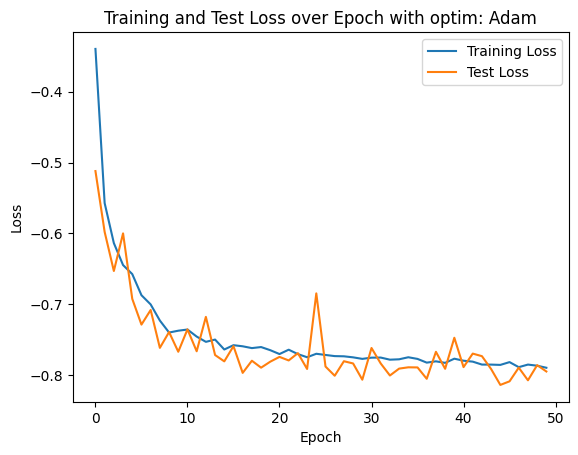

In [94]:
# pyright: basic
inn = RealNVP(input_size=2, hidden_size=128, blocks=5) 
inn = inn.to(device)
n_epochs = 50
learning_rate = 1e-3
optim = torch.optim.Adam(inn.parameters(), lr=learning_rate / 2)
#optim = Lion(inn.parameters(), lr=learning_rate/10)   
print("Using optim: ", optim.__class__.__name__)
train_loss_history ,test_loss_history = train_inn(inn, moons_traintensor,moons_testtensor, optim, n_epochs, batch_size=128)
print(f"{min(train_loss_history)=} , {min(test_loss_history)=}")
plt.plot(train_loss_history, label="Training Loss")
plt.plot(test_loss_history, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss over Epoch with optim: "+str(optim.__class__.__name__))  
plt.legend()
plt.show()

min(train_loss_history)=-0.7452201976421031 , min(test_loss_history)=-0.7556492984294891


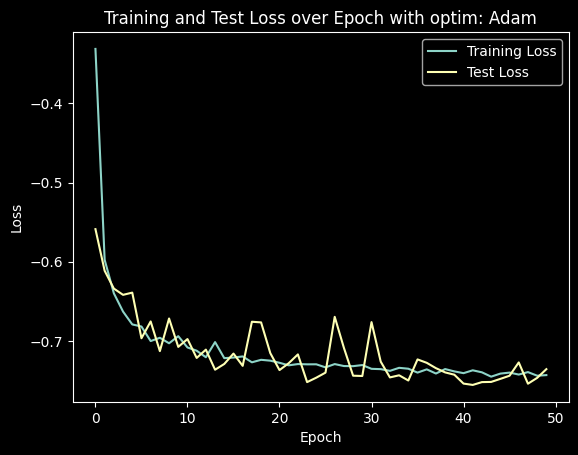

In [58]:
# pyright: basic
print(f"{min(train_loss_history)=} , {min(test_loss_history)=}")
plt.plot(train_loss_history, label="Training Loss")
plt.plot(test_loss_history, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss over Epoch with optim: "+str(optim.__class__.__name__))  
plt.legend()
plt.show()

In [59]:
# pyright: basic
inp = moons_train[[0,1,2]]
print("Moon example point: ",inp, inp.shape)
outp = inn.forward(inp)
print("Code: ", outp)
reconstructed_inp = inn.reverse(outp)
print("Reconstructed input: ", reconstructed_inp)
print("Reconstruction error: ", err:= torch.norm(inp - reconstructed_inp))
if err < 1e-4:
    print("Reconstruction successful!")
else:
    print("Reconstruction failed!")



Moon example point:  tensor([[-0.2501,  1.0785],
        [ 0.2516,  0.5482],
        [-0.6936,  0.5851]]) torch.Size([3, 2])
Code:  tensor([[-0.7876,  0.9775],
        [ 1.6337, -0.2459],
        [ 0.7866, -0.0828]], grad_fn=<MmBackward0>)
Reconstructed input:  tensor([[-0.2501,  1.0785],
        [ 0.2516,  0.5482],
        [-0.6936,  0.5851]], grad_fn=<CatBackward0>)
Reconstruction error:  tensor(2.6390e-06, grad_fn=<LinalgVectorNormBackward0>)
Reconstruction successful!


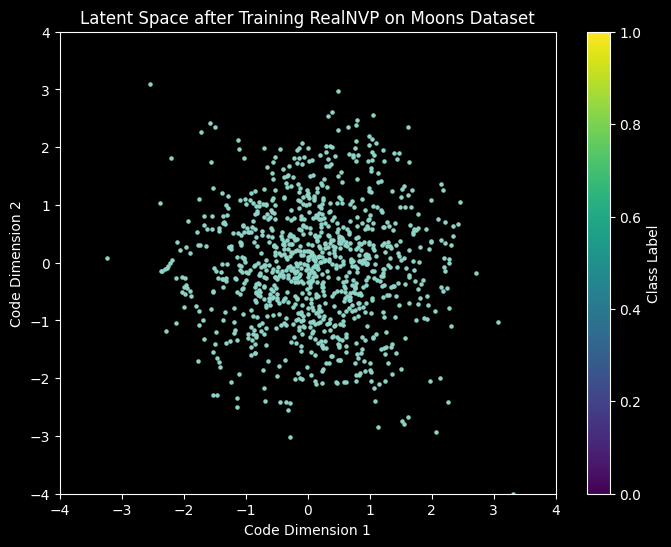

In [61]:
# pyright: basic
# code analysis:
codes = inn.forward(moons_train[:min(1000,len(moons_train))])
#codes = inn.forward(moons_train)
codes_np = codes.detach().cpu().numpy()
plt.figure(figsize=(8,6))
plt.scatter(codes_np[:,0], codes_np[:,1], s=5)
plt.title("Latent Space after Training RealNVP on Moons Dataset")
plt.xlabel("Code Dimension 1")
plt.ylabel("Code Dimension 2")
plt.xlim(-4,4)
plt.ylim(-4,4)
plt.colorbar(label="Class Label")
plt.show()


In [64]:
print(torch.cov(codes.T)) # should be close to identity matrix
print(torch.mean(codes,dim=0)) # should be close to zero

tensor([[ 0.9636, -0.0099],
        [-0.0099,  1.0853]], grad_fn=<SqueezeBackward0>)
tensor([ 0.1051, -0.0521], grad_fn=<MeanBackward1>)


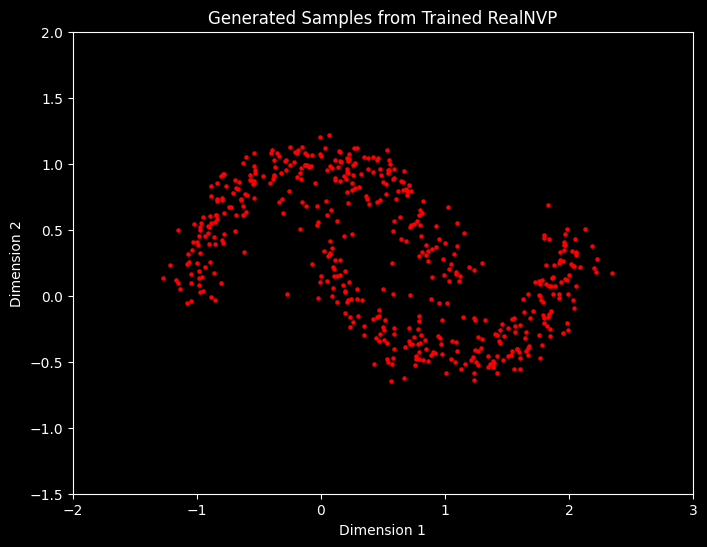

In [66]:
# pyright: basic
# test generation:
num_samples = 500
z_samples = torch.randn((num_samples, 2))  # sample from standard normal
generated_samples = inn.reverse(z_samples)
generated_samples_np = generated_samples.detach().numpy()
plt.figure(figsize=(8,6))
plt.scatter(generated_samples_np[:,0], generated_samples_np[:,1], color='red', s=5)
plt.title("Generated Samples from Trained RealNVP")
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

In [6]:
# pyright: basic
# mmd2: # from last solution
def mmd_inverse_multi_quadratic(x, y, bandwidths=None):
    batch_size = x.size()[0]
    # compute the kernel matrices for each combination of x, y
    # (cleverly using broadcasting to do this efficiently)
    xx, yy, xy = torch.mm(x,x.t()), torch.mm(y,y.t()), torch.mm(x,y.t())
    rx = (xx.diag().unsqueeze(0).expand_as(xx))
    ry = (yy.diag().unsqueeze(0).expand_as(yy))
    # compute the sum of kernels at different bandwidths
    K, L, P = 0, 0, 0
    if bandwidths is None:
        bandwidths = [0.4, 0.8, 1.6]
    for sigma in bandwidths:
        s = 1.0 / sigma**2
        K += 1.0 / (1.0 + s * (rx.t() + rx - 2.0*xx))
        L += 1.0 / (1.0 + s * (ry.t() + ry - 2.0*yy))
        P += 1.0 / (1.0 + s * (rx.t() + ry - 2.0*xy))
        beta = 1./(batch_size*(batch_size-1)*len(bandwidths))
        gamma = 2./(batch_size**2 * len(bandwidths))
    return beta * (torch.sum(K)+torch.sum(L)) - gamma * torch.sum(P)

6000
Training set size for this run: 300
MMD^2 between test set codes and standard normal: 0.0038473010063171387
min(train_losses)=-0.6368558208147684 , min(test_losses)=-0.5605576833089193


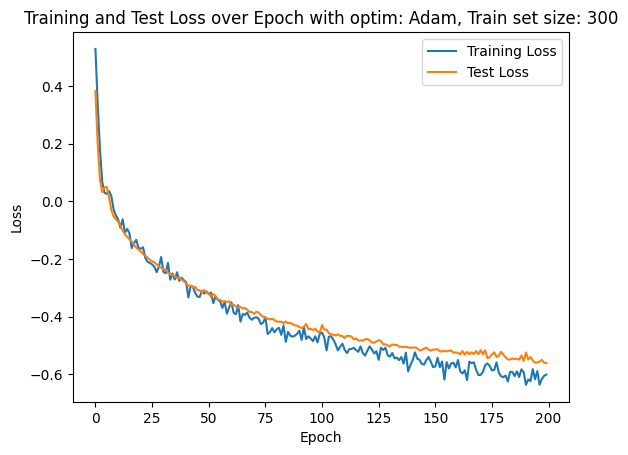

Training set size for this run: 3000
MMD^2 between test set codes and standard normal: 0.0006211996078491211
min(train_losses)=-0.780277669429779 , min(test_losses)=-0.7401516437530518


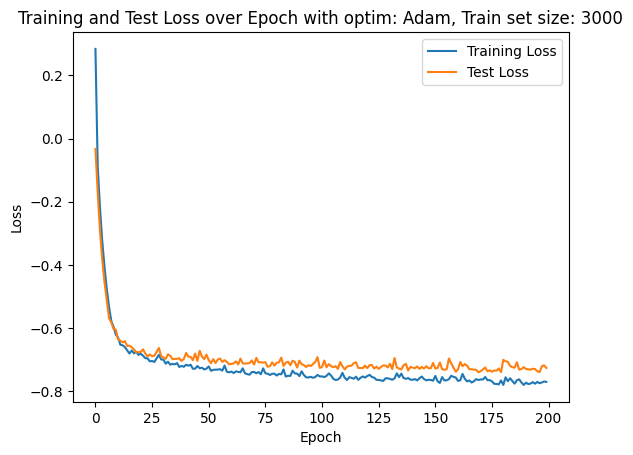

Training set size for this run: 30000
MMD^2 between test set codes and standard normal: 0.0004951357841491699
min(train_losses)=-0.8142606215274081 , min(test_losses)=-0.812800536553065


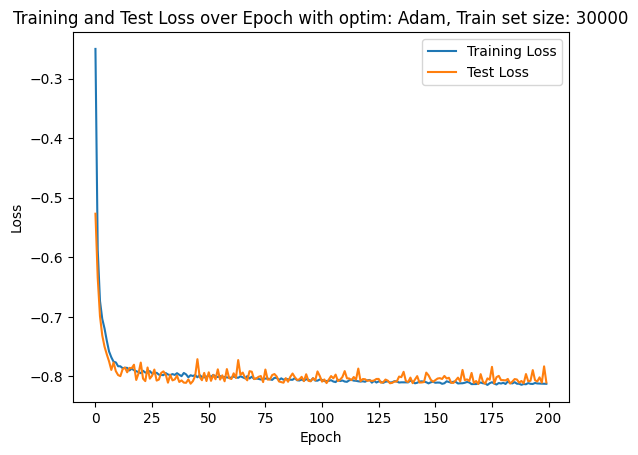

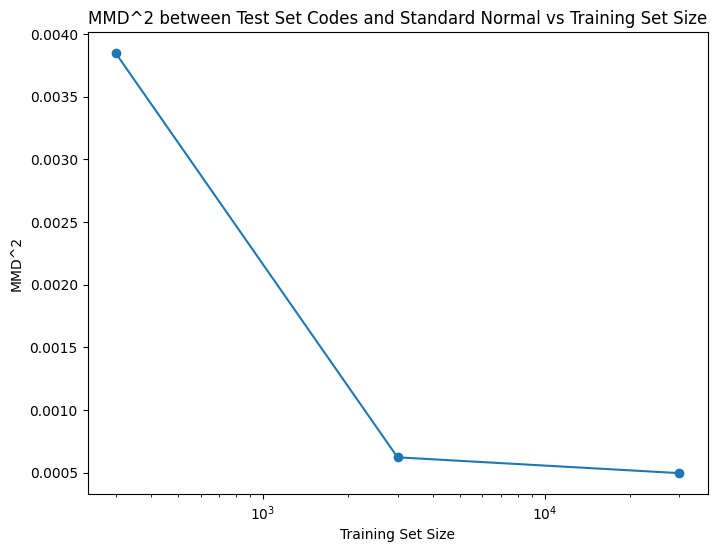

In [94]:
# pyright: basic
# Investigate systematically the effect of the hyperparameters on model quality
# the size of the training set,
#  the number of epochs,
#  and the learning rate


train_set_size = [300,3000,30000]
epochs = [2,10,30,50]
lr = [1e-5,1e-4,1e-3,1e-2]

train_size_inn = RealNVP(input_size=2, hidden_size=128, blocks=7)
train_size_inn = train_size_inn.to(device)

print(f"{moons_testtensor.__len__()}")

gaussian_sampled = torch.randn((moons_testtensor.__len__(),2)).to(device)
mmd2s = []
models_tss = []

for tss in train_set_size:
    moons_trainigset, moon_labels = make_moons(n_samples=tss, noise=0.1)
    moons_trainigset = torch.from_numpy(moons_trainigset).float()
    moons_traintensor = torch.utils.data.TensorDataset(moons_trainigset)
    
    tss_inn = RealNVP(input_size=2, hidden_size=128, blocks=7)
    tss_inn = tss_inn.to(device)
    models_tss.append(tss_inn)

    optim = torch.optim.Adam(tss_inn.parameters(), lr=1e-4)
    print(f"Training set size for this run: {tss}")
    train_losses, test_losses = train_inn(tss_inn, moons_traintensor,moons_testtensor, optim, epochs=200, batch_size=128)

    # mmd2:
    with torch.no_grad():
        coded_test = tss_inn.forward(moons_test.to(device))
        mmd2_value = mmd_inverse_multi_quadratic(coded_test, gaussian_sampled)
        print(f"MMD^2 between test set codes and standard normal: {mmd2_value.item()}")
        mmd2s.append(mmd2_value.item())



    print(f"{min(train_losses)=} , {min(test_losses)=}")
    plt.plot(train_losses, label="Training Loss")
    plt.plot(test_losses, label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Test Loss over Epoch with optim: "+str(optim.__class__.__name__) + f", Train set size: {tss}")  
    plt.legend()
    plt.show()

# plot MMD^2 values for different training set sizes:
plt.figure(figsize=(8,6))
plt.plot(train_set_size, mmd2s, marker='o')
plt.xscale('log')
plt.xlabel("Training Set Size")
plt.ylabel("MMD^2")
plt.title("MMD^2 between Test Set Codes and Standard Normal vs Training Set Size")
plt.show()

    

In [95]:
# pyright: basic
lr_list = [1e-5,1e-4,1e-3]
train_losses = []
test_losses = []
epochs = 200
print(len(moons_traintensor))
for learning_rate in lr_list:    
    lr_inn = RealNVP(input_size=2, hidden_size=192, blocks=7)
    optim = torch.optim.Adam(lr_inn.parameters(), lr=learning_rate)
    train_loss, test_loss = train_inn(lr_inn, moons_traintensor,moons_testtensor, optim, epochs=epochs, batch_size=128)
    print(f"{min(train_loss)=} , {min(test_loss)=}")
    # save train and test losses
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    


30000
min(train_loss)=-0.8074442069581215 , min(test_loss)=-0.8120748400688171
min(train_loss)=-0.8175915806851488 , min(test_loss)=-0.8174138168493906
min(train_loss)=-0.7989003922076936 , min(test_loss)=-0.8059978087743124


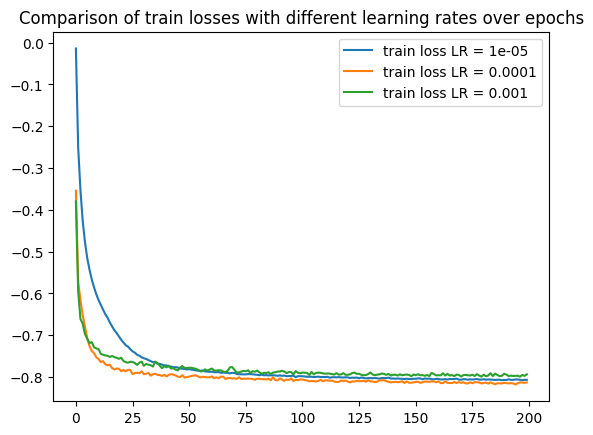

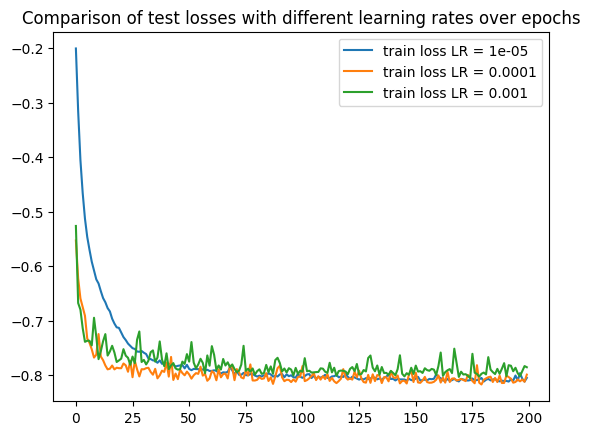

In [96]:
# pyright: basic
for index,lr in enumerate(lr_list):
    plt.plot(list(range(epochs)),train_losses[index],label = f"train loss LR = {lr}")
plt.title("Comparison of train losses with different learning rates over epochs")
plt.legend()
plt.show()
for index,lr in enumerate(lr_list):
    plt.plot(list(range(epochs)),test_losses[index],label = f"train loss LR = {lr}")
plt.title("Comparison of test losses with different learning rates over epochs")
plt.legend()
plt.show()




Comparing visuals (gaussianes of codes and sampled examples) to mmd2


/var/folders/5z/yt2pbd154078qsfzphtb5sr80000gn/T/ipykernel_39167/2585893454.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend()
/var/folders/5z/yt2pbd154078qsfzphtb5sr80000gn/T/ipykernel_39167/2585893454.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


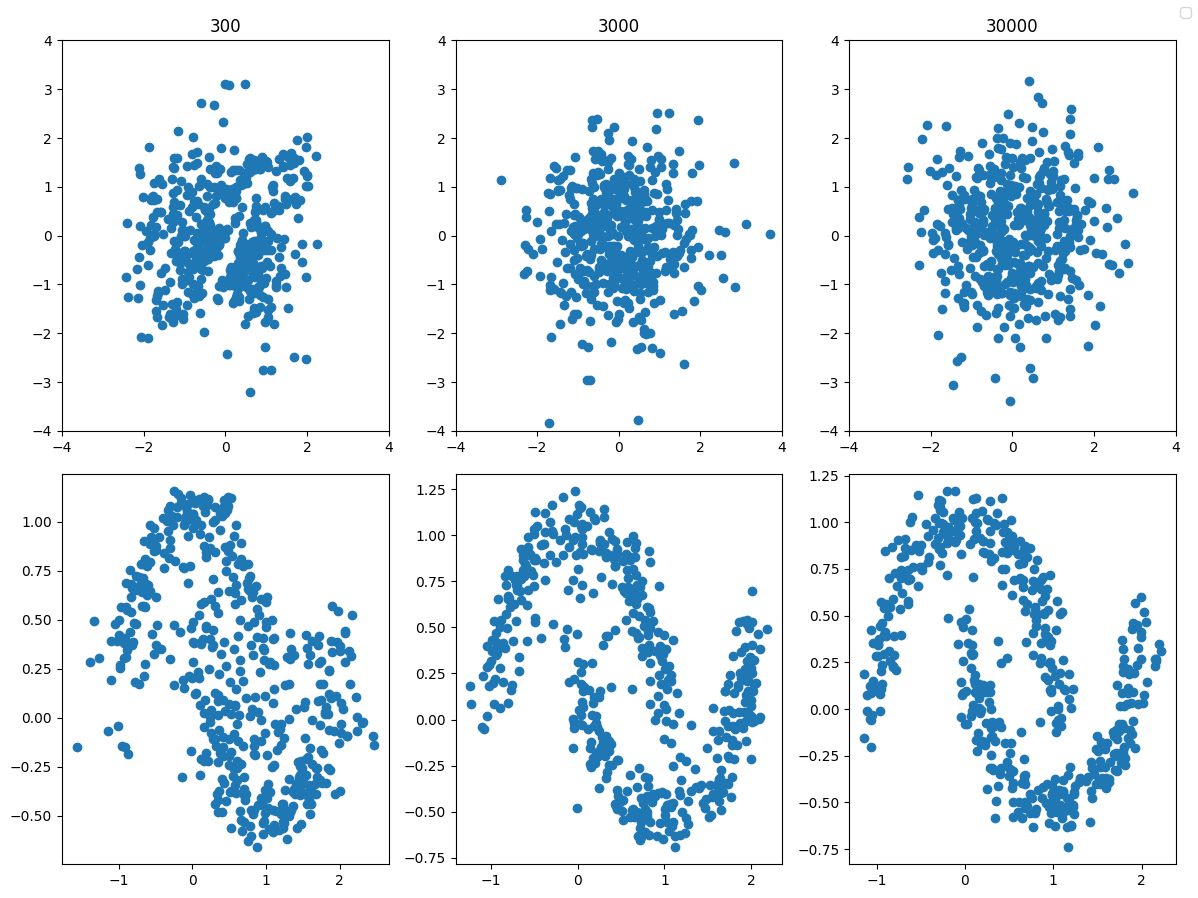

In [97]:
# pyright: basic
# now comparing good and bad models, and their mmds
print("Comparing visuals (gaussianes of codes and sampled examples) to mmd2")
tss_iter = iter(train_set_size)
fig, ax = plt.subplots(2, 3, figsize=(12, 9))

gaussians_samples = torch.randn((500,2)).to(device)
for index, ziped in enumerate(zip(models_tss,mmd2s)):
    model, mmd2 = ziped
    tss = next(tss_iter)
    # sample 500 random gaussians
    codes = model.forward(moons_test[:500]).detach().cpu().numpy()
    gaussians_samples = torch.randn((500,2))
    samples = model.reverse(gaussians_samples)
    ax[0][index].scatter(codes[:,0],codes[:,1])
    #ax[0][index].title("tss")
    ax[0][index].set_xlim(-4,4)
    ax[0][index].set_title(tss)
    samples = model.reverse(gaussians_samples).detach()
    ax[(1,index)].scatter(samples[:,0],samples[:,1])
    ax[0][index].set_ylim(-4,4)

plt.tight_layout()
fig.legend()
fig.show()

    


tensor([2, 3, 2, 0, 2, 2, 5, 3, 2, 4, 3, 3, 5, 5, 1, 0, 4, 3, 2, 0, 4, 5, 2, 0,
        5, 2, 2, 3, 5, 1])


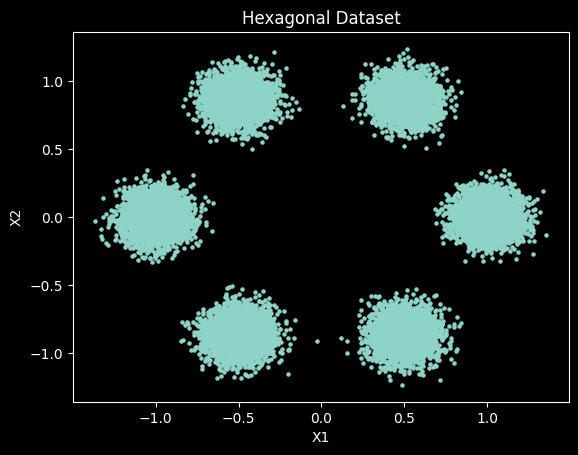

In [7]:
# pyright: basic
#GMM on the hexagonal dataset
import numpy as np

def create_dataset_hexagon(n_samples:int=30000, noise:float=0.1):
    angles = torch.linspace(0, 2 * torch.pi, steps=7)[:6]
    # we could rotate by 30 degrees = 1/12 of 2pi
    #angles = angles + (torch.pi / 6)  # rotate 
    centers = torch.stack([torch.cos(angles), torch.sin(angles)], dim=1)  # shape (6,2)
    centers_indices = np.random.choice(np.arange(len(centers)), size=n_samples)
    data = centers[centers_indices] + noise * torch.randn(n_samples, 2)
    return (data).float(), torch.tensor(centers_indices)


hex_train_data ,hex_train_indices= create_dataset_hexagon(n_samples=20000, noise=0.1)
hex_test_data ,hex_test_indices= create_dataset_hexagon(n_samples=10000, noise=0.1)
print(hex_test_indices[:30])
train_datatensor_hex = torch.utils.data.TensorDataset(hex_train_data,hex_train_indices)
test_datatensor_hex = torch.utils.data.TensorDataset(hex_test_data,hex_test_indices)

plt.scatter(hex_train_data[:,0], hex_train_data[:,1], s=5)
plt.title("Hexagonal Dataset")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

Using optim:  Adam


/opt/miniconda3/envs/newtorch/lib/python3.14/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


min(train_loss_history)=-1.6145776851921325 , min(test_loss_history)=-1.624969744682312


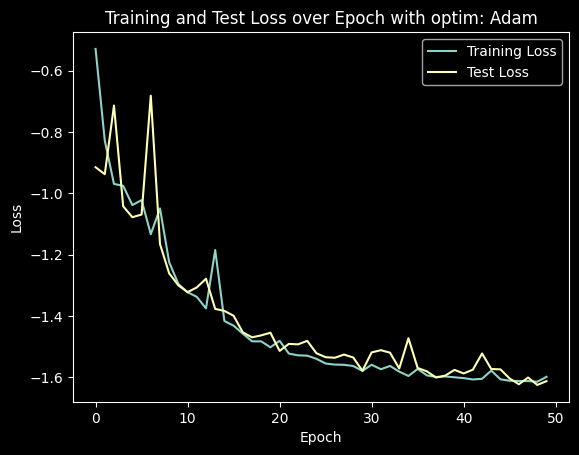

In [18]:
# pyright: basic
inn_hex = RealNVP(input_size=2, hidden_size=192, blocks=7)
inn_hex = inn_hex.to(device)
n_epochs = 50
learning_rate = 1e-3

optim = torch.optim.Adam(inn_hex.parameters(), lr=learning_rate / 10)
from lion_pytorch.cautious_lion import Lion as CLion
#optim = Lion(inn_hex.parameters(), lr=learning_rate/10)   
print("Using optim: ", optim.__class__.__name__)
train_loss_history ,test_loss_history = train_inn(inn_hex, train_datatensor_hex,test_datatensor_hex, optim, n_epochs, batch_size=128)
print(f"{min(train_loss_history)=} , {min(test_loss_history)=}")
plt.plot(train_loss_history, label="Training Loss")
plt.plot(test_loss_history, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss over Epoch with optim: "+str(optim.__class__.__name__))  
plt.legend()
plt.show()
train_loss_history_hex_one , test_loss_history_hex_one =train_loss_history ,test_loss_history

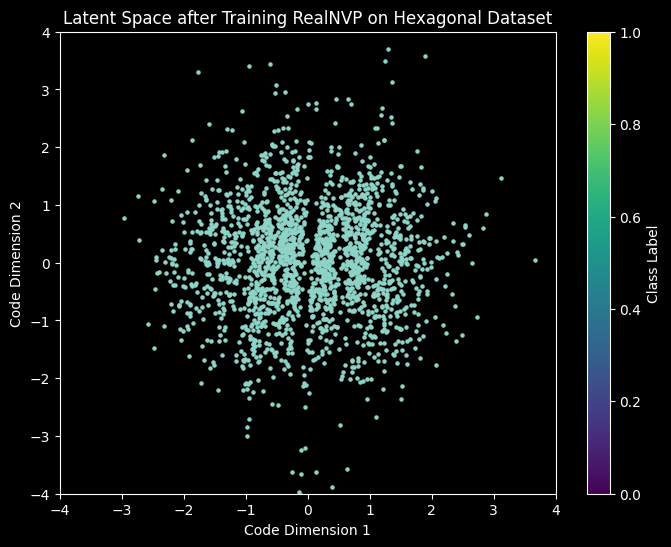

In [19]:
# pyright: basic
# code analysis:
codes = inn_hex.forward(hex_train_data[:min(2000,len(hex_train_data))])
codes_np = codes.detach().cpu().numpy()
plt.figure(figsize=(8,6))
plt.scatter(codes_np[:,0], codes_np[:,1], s=5)
plt.title("Latent Space after Training RealNVP on Hexagonal Dataset")
plt.xlabel("Code Dimension 1")
plt.ylabel("Code Dimension 2")
plt.xlim(-4,4)
plt.ylim(-4,4)
plt.colorbar(label="Class Label")
plt.show()


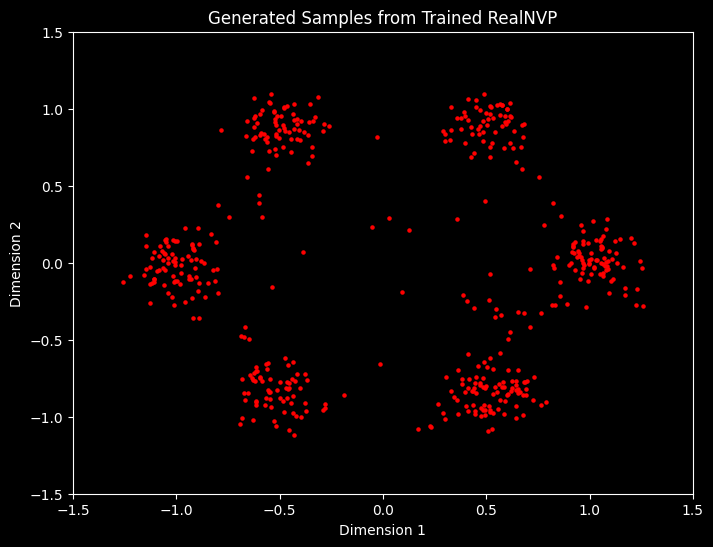

In [20]:
# pyright: basic
# test generation:
num_samples = 500
z_samples = torch.randn((num_samples, 2))  # sample from standard normal
generated_samples = inn_hex.reverse(z_samples)
generated_samples_np = generated_samples.detach().numpy()
plt.figure(figsize=(8,6))
plt.scatter(generated_samples_np[:,0], generated_samples_np[:,1], color='red', s=5)
plt.title("Generated Samples from Trained RealNVP")
plt.xlim(-1.5,1.5)
plt.ylim(-1.5,1.5)
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

Yes the hex dataset is more difficult, we need a higher hidden dim and more blocks to make it work.

### Ex 2: Two moons with conditional invertible neural network

Training set size: torch.Size([24000, 2])
Test set size: torch.Size([6000, 2])
Class distribution in training set: [11968 12032]
Class distribution in test set: [3032 2968]


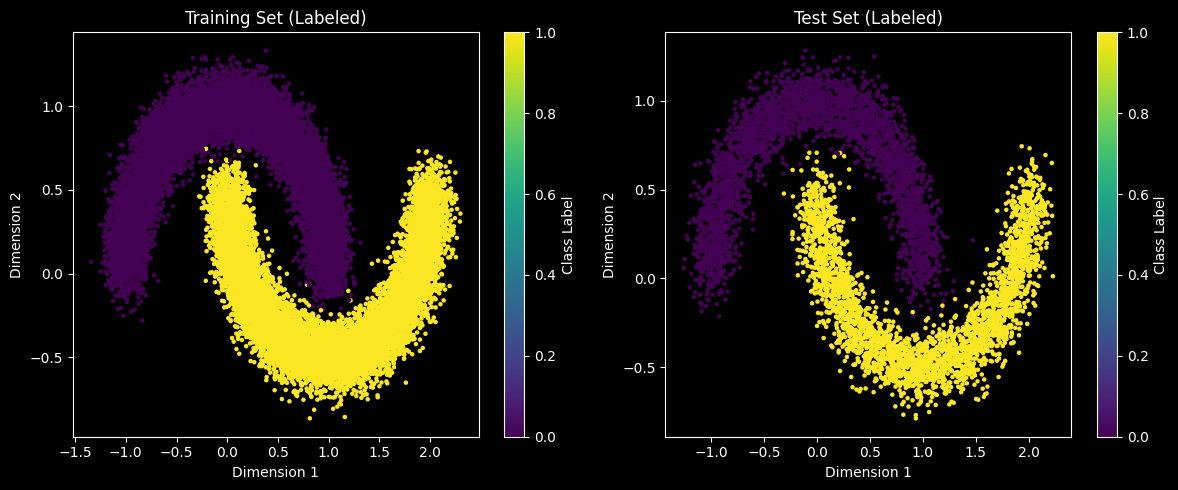


Datasets created successfully!
Train dataset: 24000 samples
Test dataset: 6000 samples


In [21]:

# pyright: basic
# task 2: Create labeled dataset using make_moons
n_samples = 30_000
noise_level = 0.1

# Generate the dataset with labels
X_moons, y_moons = make_moons(n_samples=n_samples, noise=noise_level, random_state=42067)

# Convert to torch tensors
X_moons_tensor = torch.from_numpy(X_moons).float()
y_moons_tensor = torch.from_numpy(y_moons).long()

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_moons_tensor, y_moons_tensor, test_size=0.2, random_state=42067
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Class distribution in training set: {torch.bincount(y_train).numpy()}")
print(f"Class distribution in test set: {torch.bincount(y_test).numpy()}")

# Visualize the labeled dataset
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot training set
scatter_train = axes[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', s=5)
axes[0].set_title("Training Set (Labeled)")
axes[0].set_xlabel("Dimension 1")
axes[0].set_ylabel("Dimension 2")
plt.colorbar(scatter_train, ax=axes[0], label="Class Label")

# Plot test set
scatter_test = axes[1].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis', s=5)
axes[1].set_title("Test Set (Labeled)")
axes[1].set_xlabel("Dimension 1")
axes[1].set_ylabel("Dimension 2")
plt.colorbar(scatter_test, ax=axes[1], label="Class Label")

plt.tight_layout()
plt.show()

# Create TensorDataset with both features and labels
train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
test_dataset = torch.utils.data.TensorDataset(X_test, y_test)

print(f"\nDatasets created successfully!")
print(f"Train dataset: {len(train_dataset)} samples")
print(f"Test dataset: {len(test_dataset)} samples")

loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)

In [7]:
# pyright: basic



def train_inn_cond(model:RealNVP, train_set,test_set,optim, epochs, batch_size = 128):
    scaler = GradScaler("cuda", enabled=(device.type == 'cuda'))
    train_dataloader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True,pin_memory=True) 
    test_dataloader = torch.utils.data.DataLoader(test_set, batch_size=min(len(test_set), 1000), shuffle=False,pin_memory=True)
    loss_history = []
    test_loss_history = [] 
    for epoch in range(epochs):
        epoch_loss = 0
        for batch in train_dataloader:
            X, Y  = batch # ignore label
            X = X.to(device)
            Y = Y.to(device)
            optim.zero_grad()

            with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):  # pyright: ignore[reportPrivateImportUsage]
                output = model.forward(X,to_onehot(Y,model.condition_size))
                loss = calculate_loss(model,output)
            scaler.scale(loss).backward()
            scaler.step(optim)
            scaler.update()
            epoch_loss += loss.item()
        avg_epoch_loss = epoch_loss / len(train_dataloader)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_epoch_loss:.4f}",end="\r")
        loss_history.append(avg_epoch_loss)

        # get test loss 
        test_loss = 0
        with torch.no_grad():
            for moons_testtensor in test_dataloader:
                X, Y = moons_testtensor
                X = X.to(device)
                Y = Y.to(device)
                
                output = model.forward(X,to_onehot(Y,model.condition_size))
                test_loss += calculate_loss(model,output).item()
        test_loss /= len(test_dataloader)
        test_loss_history.append(test_loss)
    return loss_history, test_loss_history

In [174]:
cond_inn = RealNVP(input_size=2, hidden_size=64, blocks=4,condition_size=2)
optim = torch.optim.Adam(cond_inn.parameters(), lr=1e-3)

train , test = train_inn_cond(cond_inn,train_dataset,test_dataset,optim,epochs=5,batch_size=128)


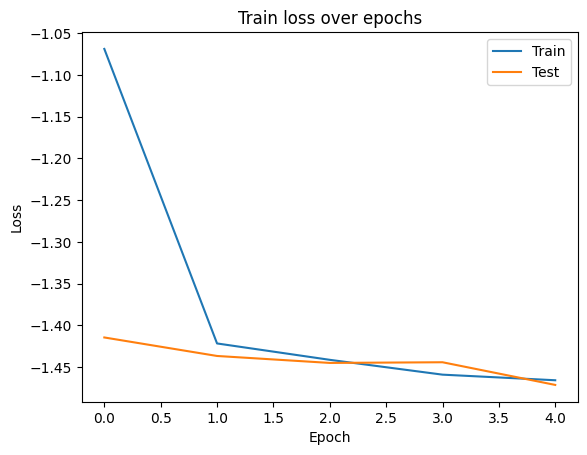

In [175]:
# pyright: basic
plt.plot(train)
plt.plot(test)
plt.legend(["Train", "Test"])
plt.title("Train loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


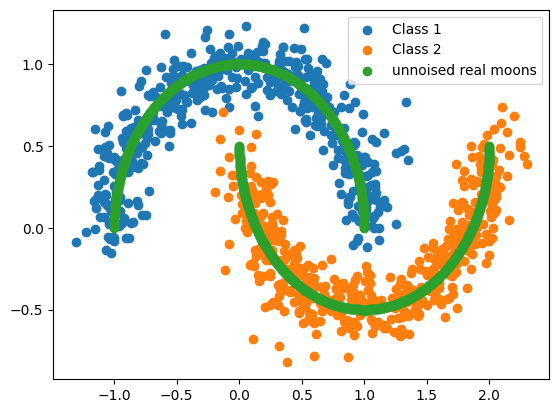

In [282]:
# pyright: basic

class_1 = torch.zeros(1)
class_2 = torch.ones(1)

# sample handles the transformation to one-hot encoding
sampled_class1 = cond_inn.sample(num_samples=500,conditions= class_1).detach().cpu().numpy()
samples_class2 = cond_inn.sample(num_samples=500,conditions= class_2).detach().cpu().numpy()

plt.scatter(sampled_class1[:,0],sampled_class1[:,1])
plt.scatter(samples_class2[:,0],samples_class2[:,1])
real = make_moons(1000, noise=0.0)[0] # real in without noise
plt.scatter(real[:,0],real[:,1])
plt.legend(["Class 1", "Class 2", "unnoised real moons"])
plt.show()

Using optim:  Adam
min(train_loss_history)=-3.603268289262322 , min(test_loss_history)=-3.5940381050109864


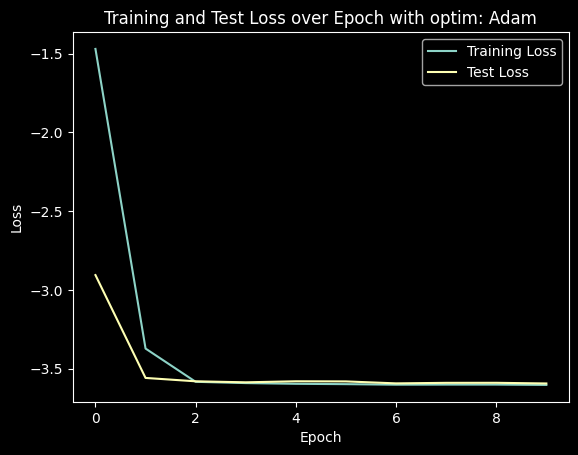

In [24]:
# now try labeled hex data

# pyright: basic


inn_hex_cond = RealNVP(input_size=2, hidden_size=192, blocks=7, condition_size=6)
inn_hex_cond = inn_hex_cond.to(device)
n_epochs = 10
learning_rate = 6e-5
schedule = torch.optim.lr_scheduler.StepLR(optim, step_size=10, gamma=0.1)
optim = torch.optim.Adam(inn_hex_cond.parameters(), lr=learning_rate)
from lion_pytorch.cautious_lion import Lion as CLion
#optim = Lion(inn_hex_cond.parameters(), lr=learning_rate/10)   
print("Using optim: ", optim.__class__.__name__)
train_loss_history ,test_loss_history = train_inn_cond(inn_hex_cond, train_datatensor_hex,test_datatensor_hex, optim, n_epochs, batch_size=128)
print(f"{min(train_loss_history)=} , {min(test_loss_history)=}")
plt.plot(train_loss_history, label="Training Loss")
plt.plot(test_loss_history, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss over Epoch with optim: "+str(optim.__class__.__name__))  
plt.legend()
plt.show()
train_loss_history_hex_six = test_loss_history
test_loss_history_hex_six = test_loss_history

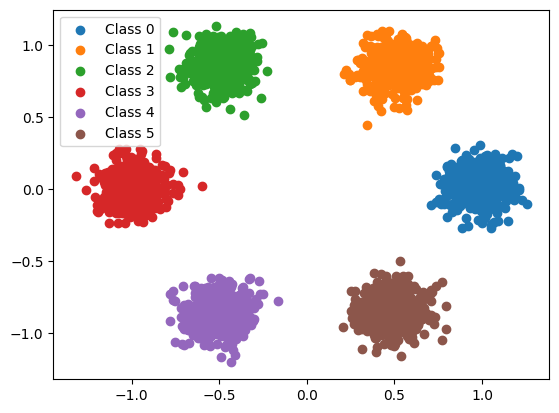

In [ ]:
# pyright: basic
class_1 = torch.zeros(1)
class_2 = torch.ones(1)

# sample handles the transformation to one-hot encoding
for cls in range(6):
    class_indicator = torch.ones(1, dtype=torch.long) * cls
    sampled_class_i = inn_hex_cond.sample(num_samples=500,conditions= class_indicator).detach().cpu().numpy()
    plt.scatter(sampled_class_i[:,0],sampled_class_i[:,1],label="Class "+str(cls))
plt.legend()
plt.show()

Using optim:  Adam


/opt/miniconda3/envs/newtorch/lib/python3.14/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


min(train_loss_history)=-2.2029799693708965 , min(test_loss_history)=-2.203885793685913


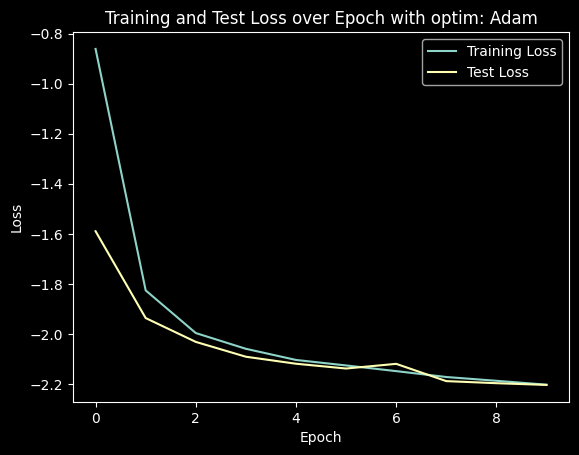

In [9]:
# now try unbalanced labeled hex data

# pyright: basic
train_unbalanced_hex =  torch.utils.data.TensorDataset(hex_train_data,torch.where( (hex_train_indices+1) % 3 == 0,0,1))
test_unbalanced_hex = torch.utils.data.TensorDataset(hex_test_data,torch.where( (hex_test_indices+1) % 3 == 0,0,1))
inn_hex_cond_unbalanced = RealNVP(input_size=2, hidden_size=192, blocks=7, condition_size=2)
inn_hex_cond_unbalanced = inn_hex_cond_unbalanced.to(device)
n_epochs = 10
learning_rate = 6e-5
# schedule = torch.optim.lr_scheduler.StepLR(optim, step_size=10, gamma=0.1)
optim = torch.optim.Adam(inn_hex_cond_unbalanced.parameters(), lr=learning_rate)
from lion_pytorch.cautious_lion import Lion as CLion
#optim = Lion(inn_hex.parameters(), lr=learning_rate/10)   
print("Using optim: ", optim.__class__.__name__)
train_loss_history ,test_loss_history = train_inn_cond(inn_hex_cond_unbalanced, train_unbalanced_hex,test_unbalanced_hex, optim, n_epochs, batch_size=128)
print(f"{min(train_loss_history)=} , {min(test_loss_history)=}")
plt.plot(train_loss_history, label="Training Loss")
plt.plot(test_loss_history, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss over Epoch with optim: "+str(optim.__class__.__name__))  
plt.legend()
plt.show()
train_loss_history_hex_two = test_loss_history
test_loss_history_hex_two = test_loss_history

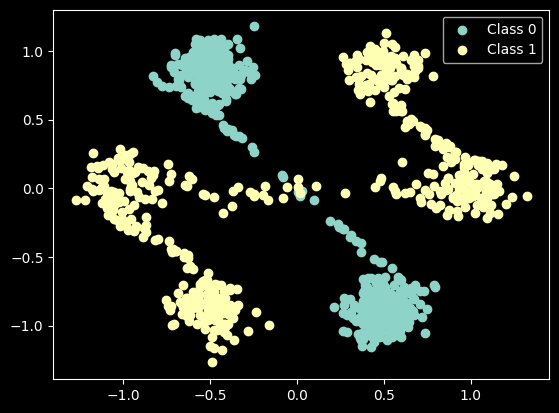

In [10]:
# pyright: basic
class_1 = torch.zeros(1)
class_2 = torch.ones(1)

# sample handles the transformation to one-hot encoding
for cls in range(2):
    class_indicator = torch.ones(1, dtype=torch.long) * cls
    sampled_class_i = inn_hex_cond_unbalanced.sample(num_samples=500,conditions= class_indicator).detach().cpu().numpy()
    plt.scatter(sampled_class_i[:,0],sampled_class_i[:,1],label="Class "+str(cls))
plt.legend()
plt.show()

they are connected by lines, but maybe we can do better with a more complex model

Using optim:  Adam
min(train_loss_history)=-2.2241024682476263 , min(test_loss_history)=-2.218090534210205


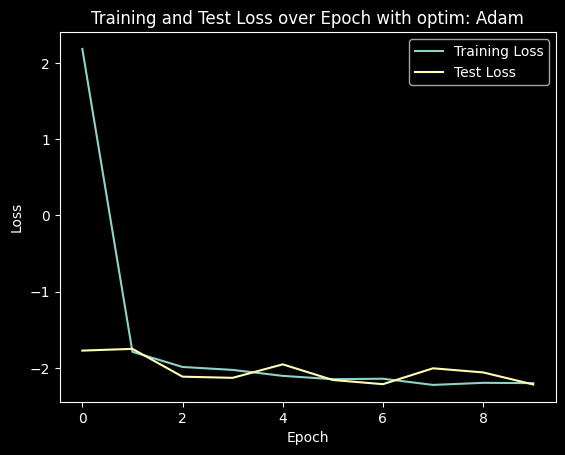

In [11]:
# bigger model

# pyright: basic
train_unbalanced_hex =  torch.utils.data.TensorDataset(hex_train_data,torch.where( (hex_train_indices+1) % 3 == 0,0,1))
test_unbalanced_hex = torch.utils.data.TensorDataset(hex_test_data,torch.where( (hex_test_indices+1) % 3 == 0,0,1))
inn_hex_cond_unbalanced_big = RealNVP(input_size=2, hidden_size=300, blocks=10, condition_size=2)
inn_hex_cond_unbalanced_big = inn_hex_cond_unbalanced_big.to(device)
n_epochs = 10
learning_rate = 1e-3

optim = torch.optim.Adam(inn_hex_cond_unbalanced_big.parameters(), lr=learning_rate)
from lion_pytorch.cautious_lion import Lion as CLion
#optim = CLion(inn_hex_cond_unbalanced.parameters(), lr=7e-5)
#optim = Lion(inn_hex.parameters(), lr=learning_rate/10)   
print("Using optim: ", optim.__class__.__name__)
train_loss_history ,test_loss_history = train_inn_cond(inn_hex_cond_unbalanced_big, train_unbalanced_hex,test_unbalanced_hex, optim, n_epochs, batch_size=128)
print(f"{min(train_loss_history)=} , {min(test_loss_history)=}")
plt.plot(train_loss_history, label="Training Loss")
plt.plot(test_loss_history, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss over Epoch with optim: "+str(optim.__class__.__name__))  
plt.legend()
plt.show()

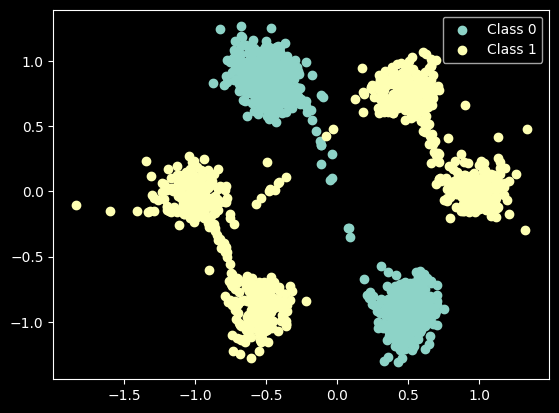

In [12]:
# pyright: basic
class_1 = torch.zeros(1)
class_2 = torch.ones(1)

# sample handles the transformation to one-hot encoding
for cls in range(2):
    class_indicator = torch.ones(1, dtype=torch.long) * cls
    sampled_class_i = inn_hex_cond_unbalanced_big.sample(num_samples=900,conditions= class_indicator).detach().cpu().numpy()
    plt.scatter(sampled_class_i[:,0],sampled_class_i[:,1],label="Class "+str(cls))
plt.legend()
plt.show()

Well it's only a bit better (also 900 vs 500 samples drawn), but im not willing to increase the network size even more.


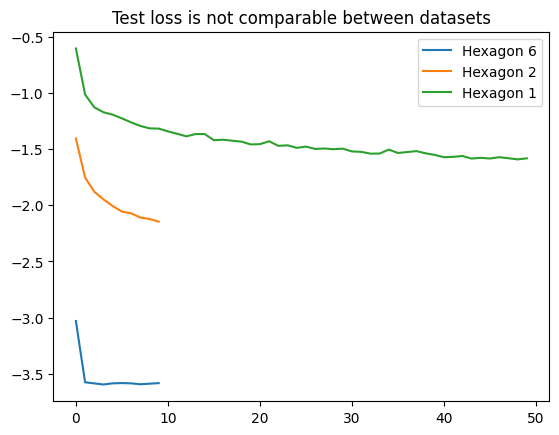

In [20]:
# pyright: basic
# compare train, test of all models
plt.plot(test_loss_history_hex_six,label = "Hexagon 6")
plt.plot(test_loss_history_hex_two,label = "Hexagon 2")
plt.plot(train_loss_history_hex_one,label = "Hexagon 1")
plt.legend()
plt.title("Test loss is not comparable between datasets")
plt.show()


In [23]:
# pyright: basic
# compare mmd2
# mmd_inverse_multi_quadratic
train_hex_samples = hex_train_data[:9996]
test_hex_samples = hex_test_data[:9996] # almost 10k
unlabeld = inn_hex.sample(num_samples=9996).detach()

two_classes_class_indicator = torch.cat((torch.zeros(3332),torch.ones(6664)),0)
print(two_classes_class_indicator.shape)
two_classes = inn_hex_cond_unbalanced.sample(num_samples=1,conditions= two_classes_class_indicator).detach()

six_classes = inn_hex_cond.sample(num_samples=1,conditions= torch.tensor([0,1,2,3,4,5]).repeat(1666)).detach()

mmd2_uncond = mmd_inverse_multi_quadratic(unlabeld,test_hex_samples)
mmd2_two_classes = mmd_inverse_multi_quadratic(two_classes,test_hex_samples)
mmd2_six_classes = mmd_inverse_multi_quadratic(six_classes,test_hex_samples)
mmd2_train = mmd_inverse_multi_quadratic(train_hex_samples,test_hex_samples)

print(mmd2_uncond)
print(mmd2_two_classes)
print(mmd2_six_classes)
print(mmd2_train)


torch.Size([9996])


NameError: name 'inn_hex_cond' is not defined

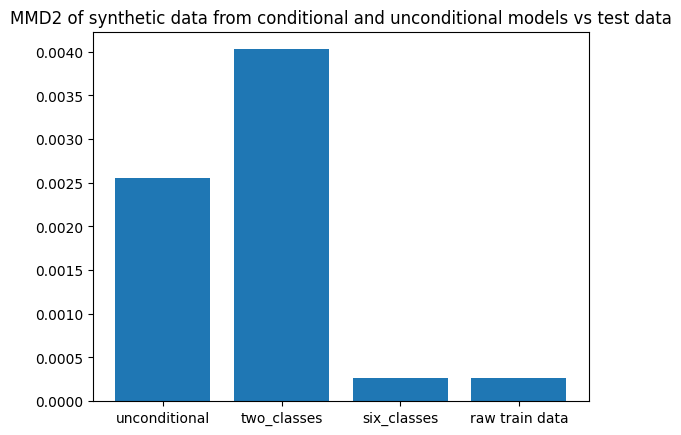

In [54]:
plt.bar(["unconditional","two_classes","six_classes","raw train data"], [mmd2_uncond,mmd2_two_classes,mmd2_six_classes,mmd2_train   ])
plt.title("MMD2 of synthetic data from conditional and unconditional models vs test data")
plt.show()

if we condition by actually different generation, it improves the score.
But the two class conditioning made the marginal score worse, indicating that we need to carefully choose how to cluster into classes. 

also note that the six classes is essentially perfect given the training data.


### EX 3: Higher-dimensional data with an INN

In [34]:
# task 3
# pyright: basic

# load digits mnist dataset:
from torchvision import datasets, transforms
import torch
import sklearn
digits = sklearn.datasets.load_digits()
# turn into torch datasetTensorDataset
X, y = digits.data, digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


X_train_tensor = torch.from_numpy(X_train).float()
y_train_tensor = torch.from_numpy(y_train).long()

X_test_tensor = torch.from_numpy(X_test).float()
y_test_tensor = torch.from_numpy(y_test).long()

# 3. Create TensorDatasets
train_dataset_digits = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
test_dataset_digits = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)

print(X_train.size)




91968


In [95]:
unconditional_digits = RealNVP(input_size=64, hidden_size=512, blocks=15)
unconditional_digits = unconditional_digits.to(device)


Using optim:  Adam
min(train_loss_history)=265.5014223845109 , min(test_loss_history)=315.0978088378906
torch.argmin(torch.tensor(test_loss_history))=tensor(99)


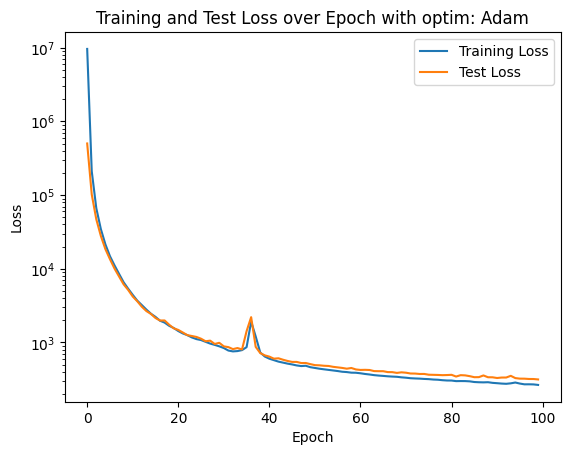

In [96]:
# pyright: basic

n_epochs = 100
learning_rate = 1e-3
optim = torch.optim.Adam(unconditional_digits.parameters(), lr=learning_rate)
from lion_pytorch.cautious_lion import Lion as CLion
#optim = Lion(unconditional_mnist.parameters(), lr=learning_rate/10)   
print("Using optim: ", optim.__class__.__name__)
train_loss_history ,test_loss_history = train_inn(unconditional_digits, train_dataset_digits,test_dataset_digits, optim, n_epochs, batch_size=64)
print(f"{min(train_loss_history)=} , {min(test_loss_history)=}")
print(f"{torch.argmin(torch.tensor(test_loss_history))=}")
plt.plot(train_loss_history, label="Training Loss")
plt.plot(test_loss_history, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss over Epoch with optim: "+str(optim.__class__.__name__))  
plt.yscale("log")
plt.legend()
plt.show()
train_loss_history_uncond_digits , test_loss_history_uncond_digits =train_loss_history ,test_loss_history

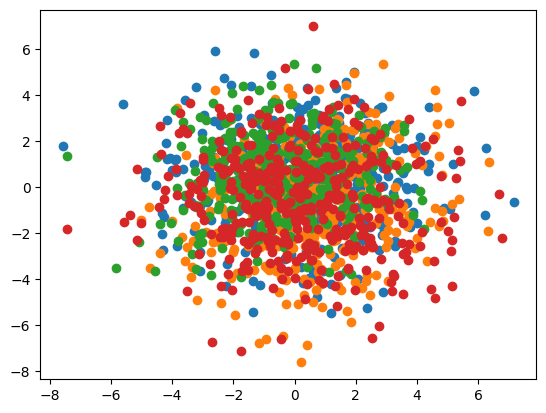

avearge abs mean over all dimensions:  0.34246027


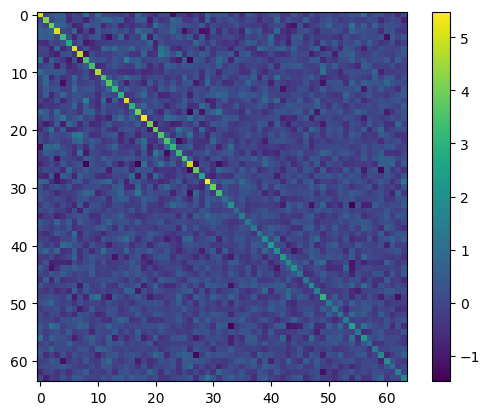

In [97]:
# pyright: basic
# make 2d projections of the codes:
codes = unconditional_digits.forward(train_dataset_digits[:400][0]).detach().cpu().numpy()

plt.scatter(codes[:,0], codes[:,1])
plt.scatter(codes[:,2], codes[:,3])
plt.scatter(codes[:,4], codes[:,5])
plt.scatter(codes[:,6], codes[:,7])
plt.show()
mean= codes.mean(axis=0)
cov = np.cov(codes, rowvar=False)
print("avearge abs mean over all dimensions: ", abs(mean).mean()) 
im = plt.imshow(cov)
plt.colorbar(im)




the cov of the codes is very interesting. it looks like its segmented into Quadrants. this is likely due to the rotations of the digits, e.g. for the first 32 dims, its nearly a identity matrix, and for the other 32 dims, it is also close but the values have higher variance.

Note that the cov matrix could be made less segmented into quadrants by applying another rotation matrix after the last coupling block, as long as this is accounted for again in the reverse pass.

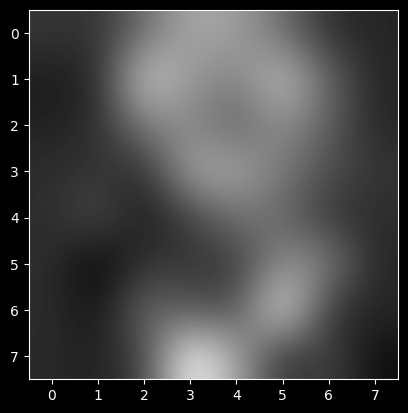

In [115]:
n= 2
digit = unconditional_digits.sample(2).reshape((2,8,8))
plt.imshow(digit[0].detach().cpu().numpy(), cmap="gray",interpolation="bicubic")



In [587]:
# bottleneck: 

# pyright: basic


mse_loss = nn.MSELoss()
def calculate_loss_reconstruction(model, codes, x, reconstruction, lambda_val = 1.):
    # target is true data, for reconstruction
    loss = 0
    for block in model.blocks:
        block:CouplingBlock
        loss -= block.block_det
    loss+= codes.pow(2).sum() / 2 # sum over all axis
    normal_loss = loss / codes.size(0)  # mean over batch
    
    # now add reconstructino loss
    reconstruction_loss = mse_loss(x, reconstruction)
    total_loss = normal_loss + lambda_val * reconstruction_loss
    print(normal_loss.item(), reconstruction_loss.item())
    return total_loss


def train_inn_reconstruction(model:RealNVP, train_set,test_set,optim, epochs, batch_size = 128, k = 4):
    k_mask = torch.zeros((1,model.input_size))
    k_mask[:,:k] = 1
    k_mask = k_mask.to(device)
    scaler = GradScaler("cuda", enabled=(device.type == 'cuda'))
    train_dataloader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True,pin_memory=True) 
    test_dataloader = torch.utils.data.DataLoader(test_set, batch_size=min(len(test_set), 1000), shuffle=False,pin_memory=True)
    loss_history = []
    test_loss_history = [] 
    for epoch in range(epochs):
        epoch_loss = 0
        for batch in train_dataloader:
            batch = batch[0].to(device) # ignore label
            optim.zero_grad()

            with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):  # pyright: ignore[reportPrivateImportUsage]
                output = model.forward(batch)

                reconstruction = model.reverse(output * k_mask)
                loss = calculate_loss_reconstruction(model,output,batch,reconstruction, lambda_val =1.)
            scaler.scale(loss).backward()
            scaler.step(optim)
            scaler.update()
            epoch_loss += loss.item()
        avg_epoch_loss = epoch_loss / len(train_dataloader)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_epoch_loss:.4f}",end="\r")
        loss_history.append(avg_epoch_loss)

        # get test loss 
        test_loss = 0
        with torch.no_grad():
            for moons_testtensor in test_dataloader:
                moons_testtensor = moons_testtensor[0].to(device)
                output = model.forward(moons_testtensor)
                test_loss += calculate_loss(model,output).item()
        test_loss /= len(test_dataloader)
        test_loss_history.append(test_loss)
    return loss_history, test_loss_history


In [592]:
# pyright: basic
bottleneck_inn = RealNVP(input_size=64, hidden_size=24, blocks=5, condition_size=0)
bottleneck_inn = bottleneck_inn.to(device)
learning_rate = 1e-3
optim = torch.optim.Adam(bottleneck_inn.parameters(), lr=learning_rate)
#optim = Lion(bottleneck_inn.parameters(), lr=learning_rate)
train_loss_history_bottleneck_digits , test_loss_history_bottleneck_digits = [],[]

In [576]:
for param_group in optim.param_groups:
        param_group['lr'] = 1e-4

Using optim:  Adam
6159.9541015625 61.6966667175293
5088.8740234375 60.612876892089844
4247.30908203125 62.023223876953125
3567.776611328125 59.788692474365234
2637.70068359375 56.241580963134766
2339.669189453125 55.2230339050293
2051.27685546875 55.26376724243164
1808.7034912109375 54.948143005371094
1583.6524658203125 54.552642822265625
1510.42333984375 53.610015869140625
1339.182861328125 54.414405822753906
1391.897216796875 54.72114562988281
1204.4154052734375 53.11982345581055
1141.9176025390625 54.544029235839844
1085.212158203125 51.51831817626953
1014.048095703125 53.11320495605469
993.2698364257812 52.06088638305664
948.316162109375 52.6600456237793
892.4363403320312 53.05615997314453
872.3300170898438 51.70724868774414
851.5164794921875 52.38054275512695
836.4495849609375 53.46660614013672
769.968505859375 51.635597229003906
750.0242309570312 50.811893463134766
714.4474487304688 52.33708953857422
673.6881103515625 50.94823455810547
675.6672973632812 52.166908264160156
657.74

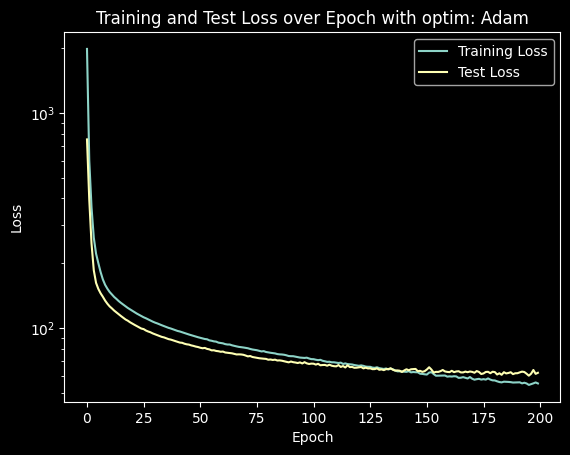

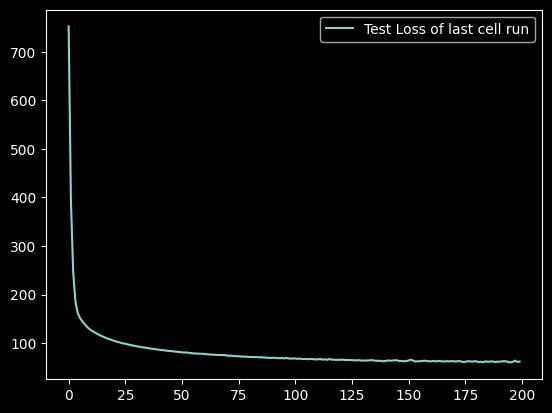

In [594]:
# pyright: basic
# update adam lr

n_epochs = 200

from lion_pytorch.cautious_lion import Lion as CLion
#optim = Lion(unconditional_mnist.parameters(), lr=learning_rate/10)   
print("Using optim: ", optim.__class__.__name__)
train_loss_history ,test_loss_history = train_inn_reconstruction(bottleneck_inn, train_dataset_digits,test_dataset_digits, optim, n_epochs, batch_size=64,k=4)
print(f"{min(train_loss_history)=} , {min(test_loss_history)=}")
print(f"{torch.argmin(torch.tensor(test_loss_history))=}")

train_loss_history_bottleneck_digits.extend(train_loss_history) 
test_loss_history_bottleneck_digits.extend(test_loss_history)
plt.plot(train_loss_history_bottleneck_digits, label="Training Loss")
plt.plot(test_loss_history_bottleneck_digits, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss over Epoch with optim: "+str(optim.__class__.__name__))  
plt.yscale("log")
plt.legend()
plt.show()
plt.plot(test_loss_history,label="Test Loss of last cell run")
plt.legend()
plt.show()

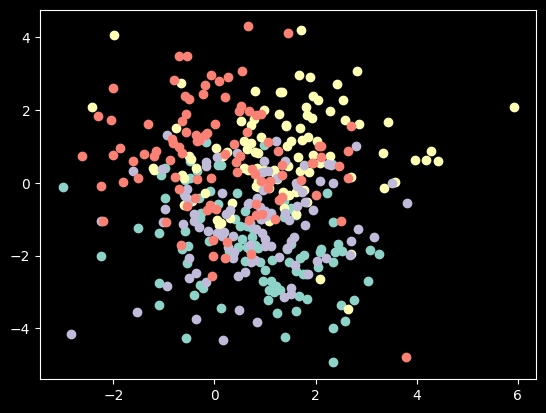

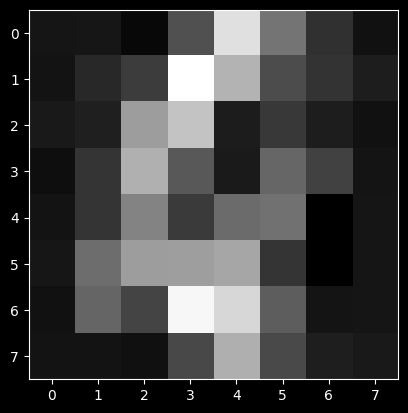

avearge abs mean over all dimensions:  2.1440017


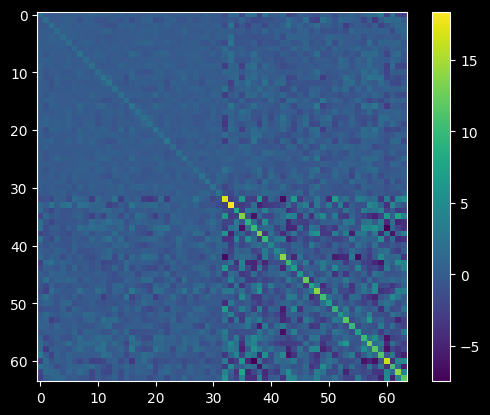

In [595]:
# pyright: basic
# make 2d projections of the codes:
codes = bottleneck_inn.forward(torch.randn((100, 64))).detach().cpu().numpy()

plt.scatter(codes[:,0], codes[:,1])
plt.scatter(codes[:,2], codes[:,3])
plt.scatter(codes[:,4], codes[:,5])
plt.scatter(codes[:,6], codes[:,7])
plt.show()

reconstructed = bottleneck_inn.sample(1).detach().cpu().numpy()
plt.imshow(reconstructed.reshape((8,8)),cmap="gray",interpolation="nearest")
plt.show()



codes = bottleneck_inn.forward(torch.randn((1000, 64))).detach().cpu().numpy()
mean= codes.mean(axis=0)
cov = np.cov(codes, rowvar=False)
print("avearge abs mean over all dimensions: ", abs(mean).mean()) 


im = plt.imshow(cov,)
plt.colorbar(im)




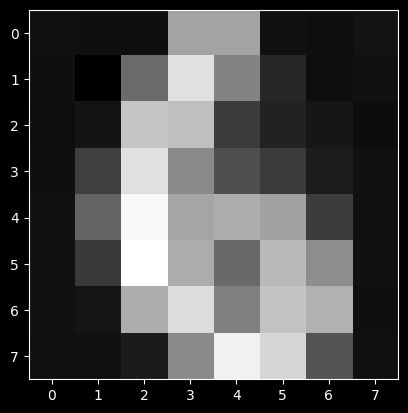

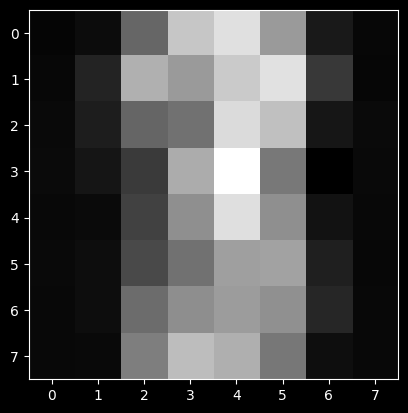

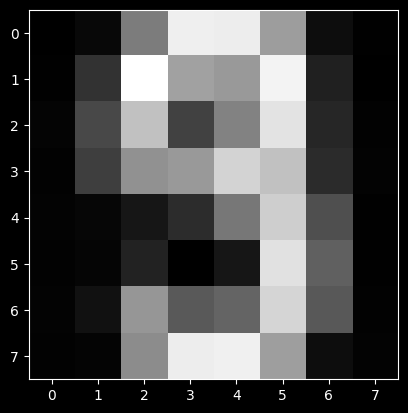

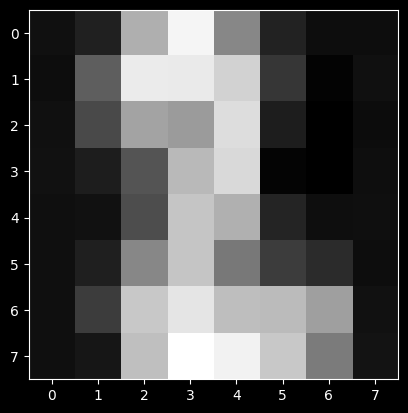

second


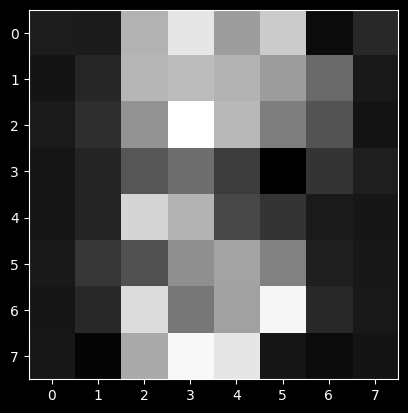

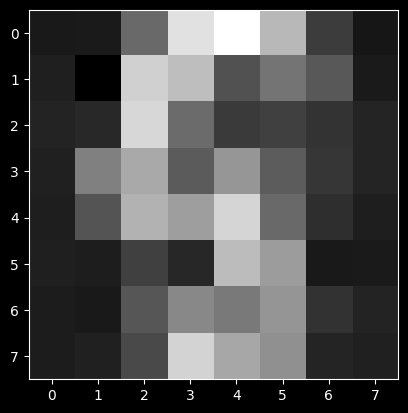

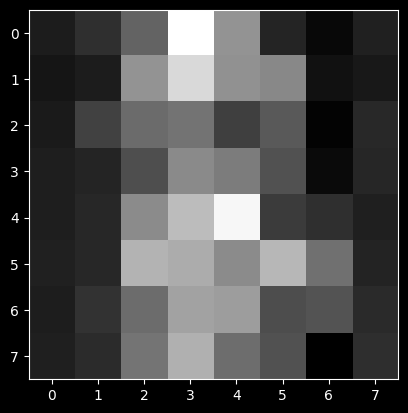

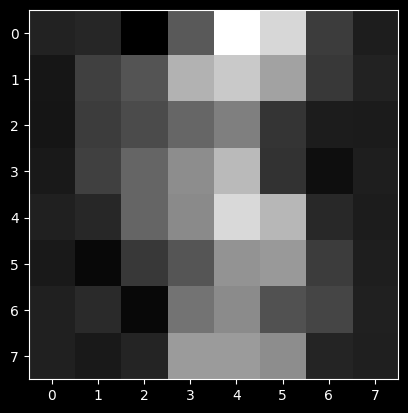

In [597]:
# pyright: basic
# now sample from this bottlenecked inn

# first method: 0..k: gaussian , k.. = 0
n = 4
k = 4
codes = torch.randn((n,64))
zeros = torch.zeros((n,64-k))
codes[:, k:] = zeros

sampled = bottleneck_inn.reverse(codes).reshape((n,8,8))
for i in range(n):
    plt.imshow(sampled[i].detach().cpu().numpy(), cmap='gray',interpolation="nearest")
    plt.show()

print("second")
# second method: 0..k = vec , k.. = gaussian
codes = torch.randn((n,64))
codes[:, :k] = torch.zeros((n,k))
sampled = bottleneck_inn.reverse(codes).reshape((n,8,8))
for i in range(n):
    plt.imshow(sampled[i].detach().cpu().numpy(), cmap='gray',interpolation="nearest")
    plt.show()

The samples are slightly better, but sitll often not recognizable.

The second method seems to work worse and chaotic


In [2]:
# provided code:
# pyright: basic
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from PIL import Image, ImageFilter  # install 'pillow' to get PIL
import matplotlib.pyplot as plt

# define a functor to downsample images
class DownsampleTransform:
    def __init__(self, target_shape, algorithm=Image.Resampling.LANCZOS):
        self.width, self.height = target_shape
        self.algorithm = algorithm

    def __call__(self, img):
        # Resize to (width+2, height+2) first using the specified algorithm
        img = img.resize((self.width + 2, self.height + 2), self.algorithm)
        # Crop to (width, height) by removing a 1-pixel border
        img = img.crop((1, 1, self.width + 1, self.height + 1))
        return img

# concatenate a few transforms
transform = transforms.Compose([
    DownsampleTransform(target_shape=(8, 8)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

# download MNIST
mnist_dataset = datasets.MNIST(
    root='./data',
    transform=transform,
    train=True,
    download=True
)
mnist_test = datasets.MNIST(
    root='./data',
    transform=transform,
    train=False,
    download=True
)


# create a DataLoader that serves minibatches of size 100
data_loader = DataLoader(
    mnist_dataset,
    batch_size=100,
    shuffle=False
)
data_loader_test = DataLoader(
    mnist_test,
    batch_size=100,
    shuffle=False
)

# visualize the first batch of downsampled MNIST images
def show_first_batch(data_loader):
    for batch in data_loader:
        x, y = batch
        fig = plt.figure(figsize=(10, 10))
        for i, img in enumerate(x):
            if i >= 100: # Ensure we don't try to plot more than 100 images
                break
            ax = fig.add_subplot(10, 10, i + 1)
            ax.imshow(img.reshape(8, 8), cmap='gray') # Reshape from (1, 8, 8) to (8, 8) for display
            ax.axis('off')
        plt.show()
        break # Only process the first batch



Using downloaded and verified file: ./data\MNIST\raw\train-images-idx3-ubyte.gz
Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Using downloaded and verified file: ./data\MNIST\raw\train-labels-idx1-ubyte.gz
Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:03<00:00, 530384.05it/s]


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 4182333.43it/s]

Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw



In [129]:
# pyright: basic

mnist_tensor_transformed = torch.cat([batch[0].reshape(-1,64) for batch in data_loader], dim=0)
mnist_tensor_transformed_label = torch.cat([batch[1] for batch in data_loader], dim=0) 

mnist_tensor_transformed_test = torch.cat([batch[0].reshape(-1,64) for batch in data_loader_test], dim=0)
mnist_tensor_transformed_label_test = torch.cat([batch[1] for batch in data_loader_test], dim=0) 


train_tensor_mnist = torch.utils.data.TensorDataset(mnist_tensor_transformed* 16., mnist_tensor_transformed_label)
test_tensor_mnist = torch.utils.data.TensorDataset(mnist_tensor_transformed_test* 16., mnist_tensor_transformed_label_test)

print(len(train_tensor_mnist))
print(len(test_tensor_mnist))


60000
10000


tensor(16.)


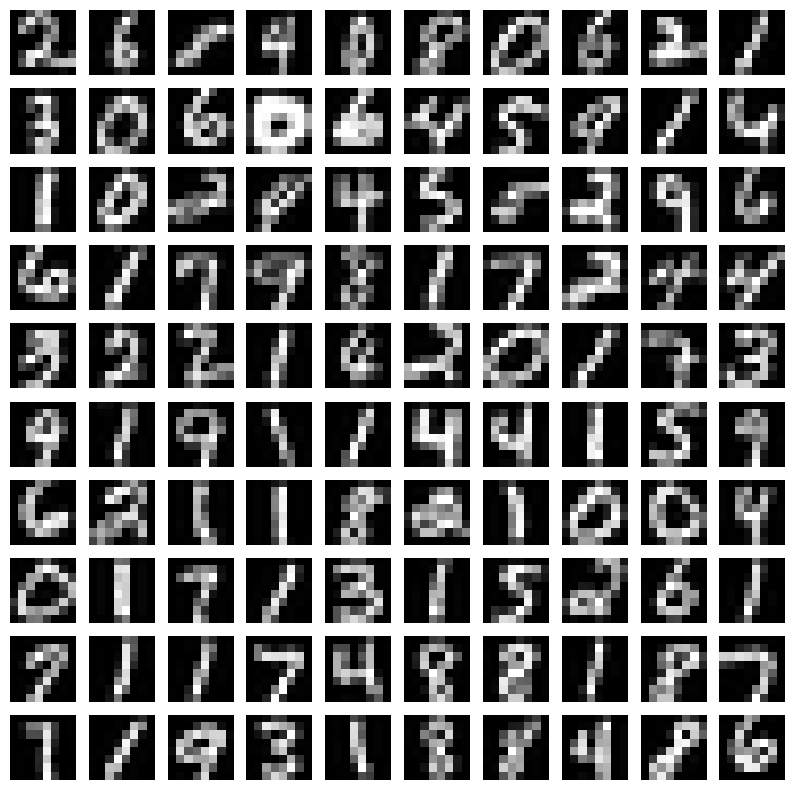

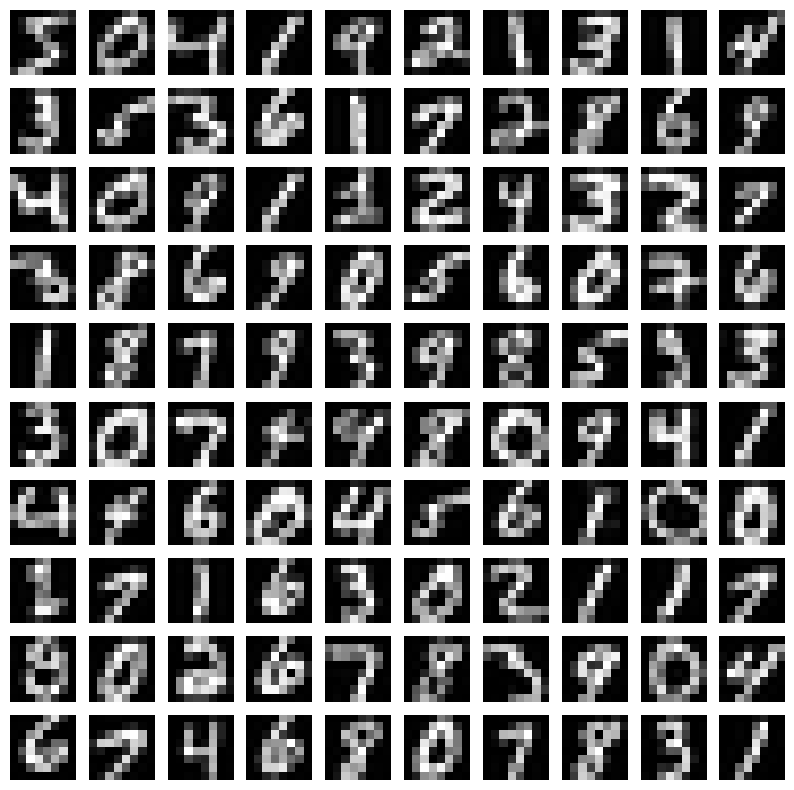

In [130]:
exp_data_loader = DataLoader(
    train_tensor_mnist,
    batch_size=100,
    shuffle=True
)
print(next(iter(exp_data_loader))[0].max())
show_first_batch(exp_data_loader)
show_first_batch(data_loader)

In [154]:
unconditional_mnist = RealNVP(input_size=64, hidden_size=32, blocks=7)
unconditional_mnist = unconditional_mnist.to(device)
train_loss_history_uncond_mnist , test_loss_history_uncond_mnist = [] ,[]

In [155]:

learning_rate = 1e-2
optim = torch.optim.Adam(unconditional_mnist.parameters(), lr=learning_rate)

In [137]:
for param_group in optim.param_groups:
        param_group['lr'] = 1e-3

Using optim:  Adam


2839.50s - thread._ident is None in _get_related_thread!


min(train_loss_history)=72.42855834960938 , min(test_loss_history)=71.42266464233398
torch.argmin(torch.tensor(test_loss_history))=tensor(19)


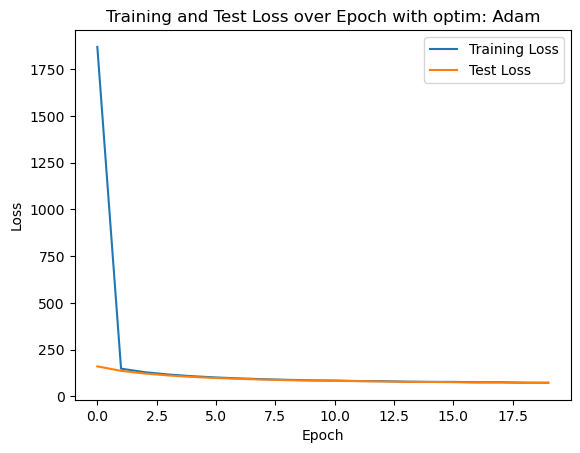

In [156]:
# pyright: basic
n_epochs = 20

from lion_pytorch.cautious_lion import Lion as CLion
#optim = Lion(unconditional_mnist.parameters(), lr=learning_rate/10)   
print("Using optim: ", optim.__class__.__name__)
train_loss_history ,test_loss_history = train_inn(unconditional_mnist, train_tensor_mnist,test_tensor_mnist, optim, n_epochs, batch_size=3000)
print(f"{min(train_loss_history)=} , {min(test_loss_history)=}")
print(f"{torch.argmin(torch.tensor(test_loss_history))=}")

train_loss_history_uncond_mnist.extend(train_loss_history) 
test_loss_history_uncond_mnist.extend(test_loss_history)

plt.plot(train_loss_history_uncond_mnist, label="Training Loss")
plt.plot(test_loss_history_uncond_mnist, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss over Epoch with optim: "+str(optim.__class__.__name__))  
#plt.yscale("log")
plt.legend()
plt.show()


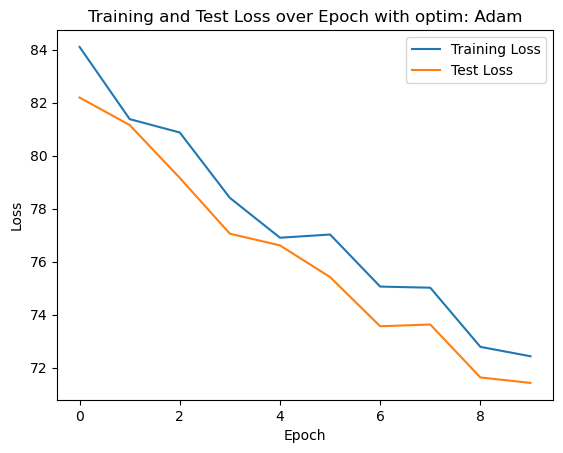

cpu


In [157]:
plt.plot(train_loss_history_uncond_mnist[10:], label="Training Loss")
plt.plot(test_loss_history_uncond_mnist[10:], label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss over Epoch with optim: "+str(optim.__class__.__name__))  
#plt.yscale("log")
plt.legend()
plt.show()
print(device)

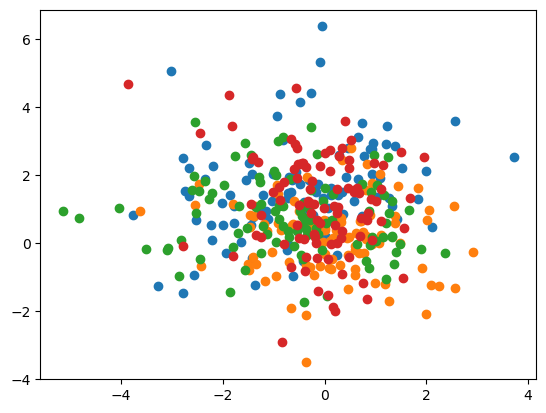

avearge abs mean over all dimensions:  0.72794586


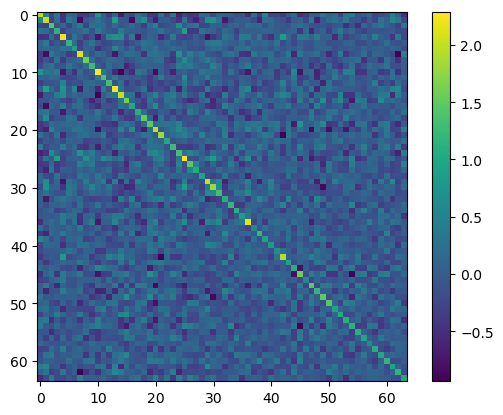

In [158]:
# pyright: basic
# make 2d projections of the codes:
codes = unconditional_mnist.forward(torch.randn((100, 64),device=device)).detach().cpu().numpy()

plt.scatter(codes[:,0], codes[:,1])
plt.scatter(codes[:,2], codes[:,3])
plt.scatter(codes[:,4], codes[:,5])
plt.scatter(codes[:,6], codes[:,7])
plt.show()
mean= codes.mean(axis=0)
import numpy as np
cov = np.cov(codes, rowvar=False)
print("avearge abs mean over all dimensions: ", abs(mean).mean()) 
im = plt.imshow(cov)
plt.colorbar(im)




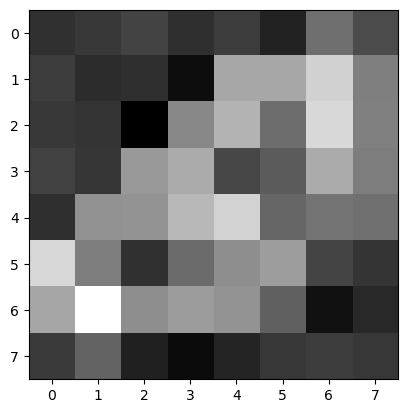

In [136]:
n= 2
digit = unconditional_mnist.sample(2).reshape((2,8,8))
plt.imshow(digit[0].detach().cpu().numpy(), cmap="gray",interpolation="nearest")



### EX 4: Higher dimensional data with a conditional INN

With our 64-dim dataset we tune training hyperparameters and then check if varying width of the internal networks, as well as number of coupling blocks improves the model.

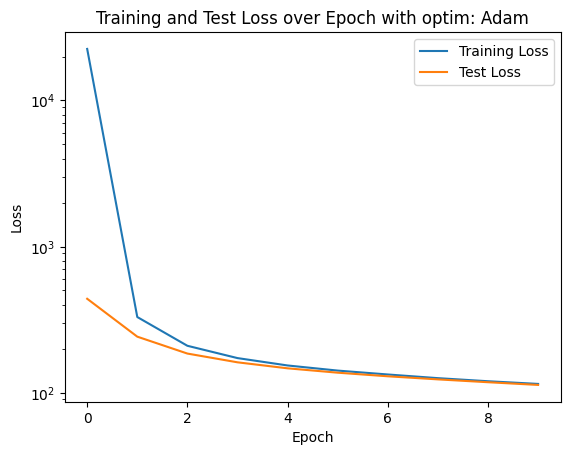

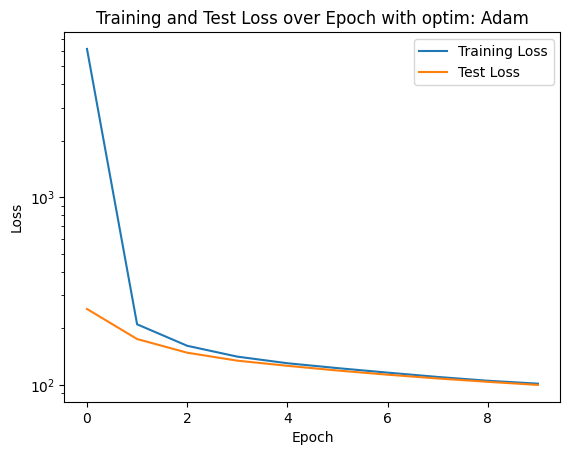

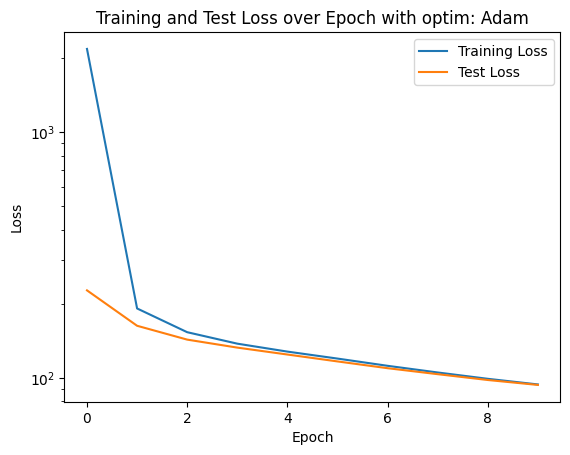

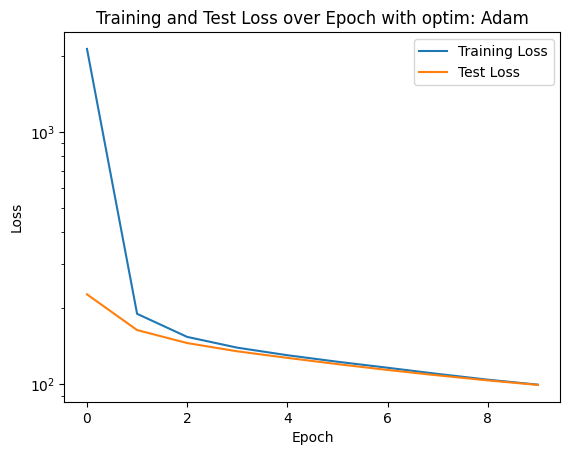

In [25]:
training_size = [3000, 10000, 50000,90000]

for ts in training_size:
    cinn = RealNVP(input_size=64, hidden_size=128, blocks=8, condition_size=10)
    cinn = cinn.to(device)
    optim = torch.optim.Adam(cinn.parameters(), lr=0.001)
    X_train = X_train[:ts]
    y_train = y_train[:ts]
    X_train_tensor = torch.from_numpy(X_train).float()
    y_train_tensor = torch.from_numpy(y_train).long()
    train_dataset_digits = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
    train_loss, test_loss = train_inn_cond(model=cinn, train_set=train_dataset_digits, test_set= test_dataset_digits, optim=optim, epochs= 10)
    plt.plot(train_loss, label="Training Loss")
    plt.plot(test_loss, label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Test Loss over Epoch with optim: "+str(optim.__class__.__name__))  
    plt.yscale("log")
    plt.legend()
    plt.show()

90_000 training points looks the best, we fix this and move on to num_batches

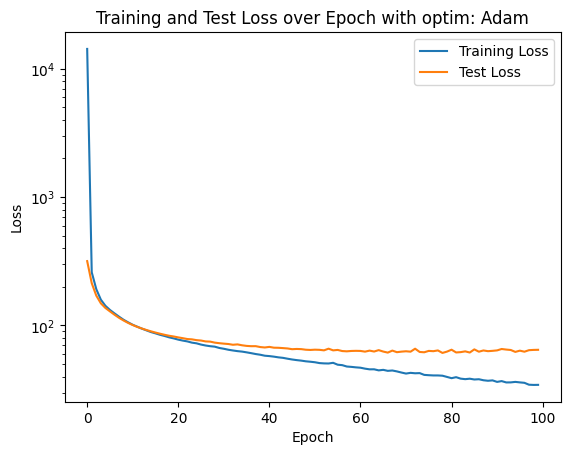

In [26]:
cinn = RealNVP(input_size=64, hidden_size=128, blocks=8, condition_size=10)
cinn = cinn.to(device)  
optim = torch.optim.Adam(cinn.parameters(), lr=0.001)
X_train = X_train[:90000]
y_train = y_train[:90000]
X_train_tensor = torch.from_numpy(X_train).float()
y_train_tensor = torch.from_numpy(y_train).long()
train_dataset_digits = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
train_loss, test_loss = train_inn_cond(model=cinn, train_set=train_dataset_digits, test_set= test_dataset_digits, optim=optim, epochs= 100)
plt.plot(train_loss, label="Training Loss")
plt.plot(test_loss, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")
plt.title("Training and Test Loss over Epoch with optim: "+str(optim.__class__.__name__) )  
plt.legend()
plt.show()

we fix a number of epochs of 20, because otherwise training error decreases, but not the test error:(

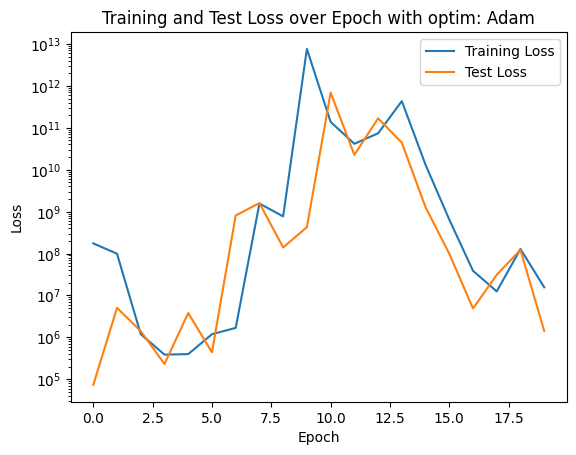

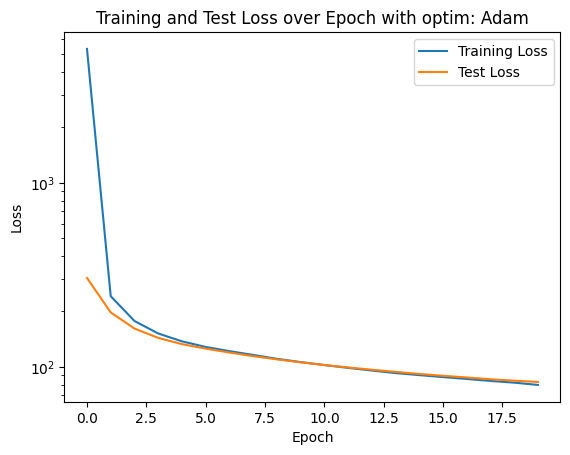

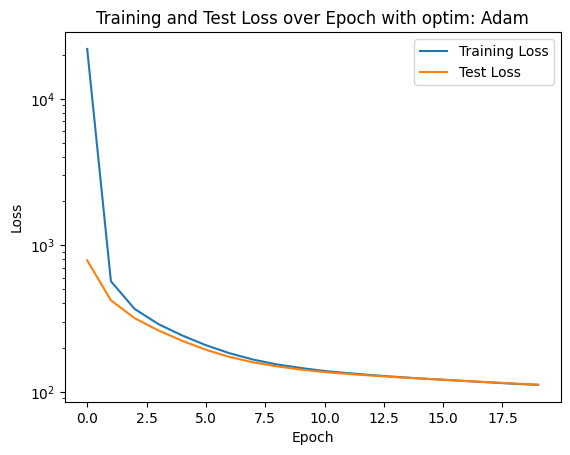

In [24]:
learningrates = [0.05,0.001,0.0005]
for lr in learningrates:
    cinn = RealNVP(input_size=64, hidden_size=128, blocks=8, condition_size=10)
    cinn = cinn.to(device)  
    optim = torch.optim.Adam(cinn.parameters(), lr=lr)
    X_train = X_train[:90000]
    y_train = y_train[:90000]
    X_train_tensor = torch.from_numpy(X_train).float()
    y_train_tensor = torch.from_numpy(y_train).long()
    train_dataset_digits = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
    train_loss, test_loss = train_inn_cond(model=cinn, train_set=train_dataset_digits, test_set= test_dataset_digits, optim=optim, epochs= 20)
    plt.plot(train_loss, label="Training Loss")
    plt.plot(test_loss, label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.yscale("log")
    plt.title("Training and Test Loss over Epoch with optim: "+str(optim.__class__.__name__) )  
    plt.legend()
    plt.show()

we choose 0.001 lr

we still check if a higher/lower num blocks, width size make the error better

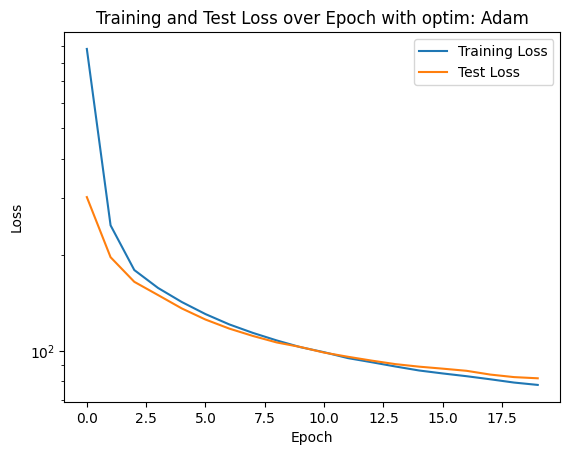

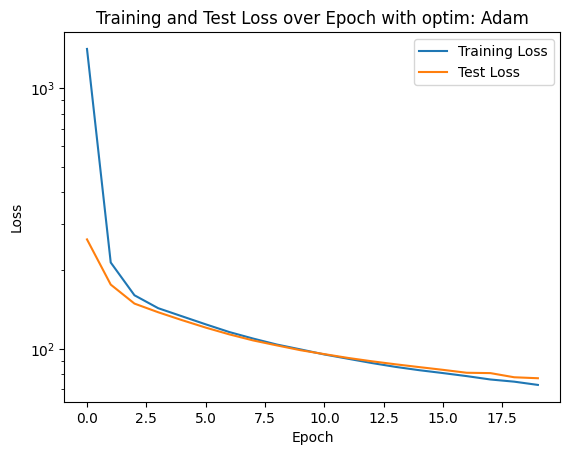

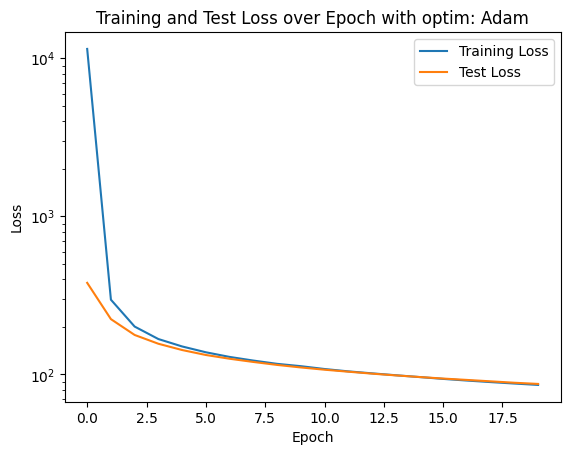

In [27]:
blocks = [3,5,8]
for bl in blocks:
    cinn = RealNVP(input_size=64, hidden_size=128, blocks=bl, condition_size=10)
    cinn = cinn.to(device)
    optim = torch.optim.Adam(cinn.parameters(), lr=0.001)
    train_loss, test_loss = train_inn_cond(model=cinn, train_set=train_dataset_digits, test_set= test_dataset_digits, optim=optim, epochs= 20)
    plt.plot(train_loss, label="Training Loss")
    plt.plot(test_loss, label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.yscale("log")
    plt.title("Training and Test Loss over Epoch with optim: "+str(optim.__class__.__name__) )  
    plt.legend()
    plt.show()


we choose 5 blocks

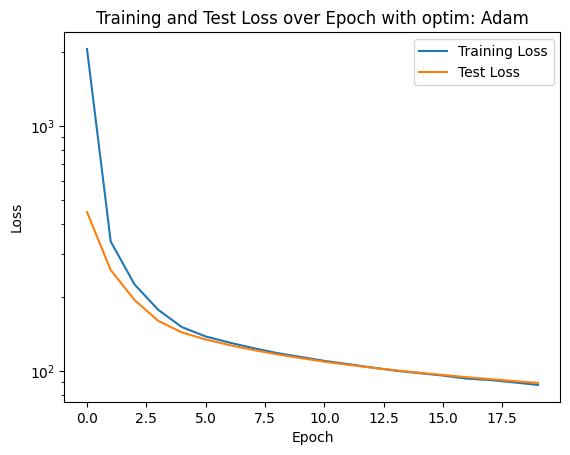

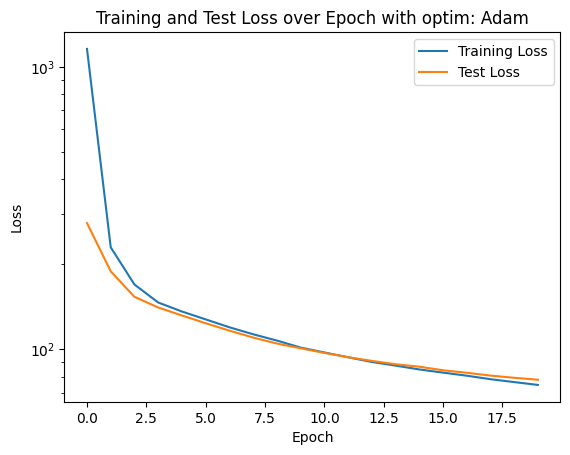

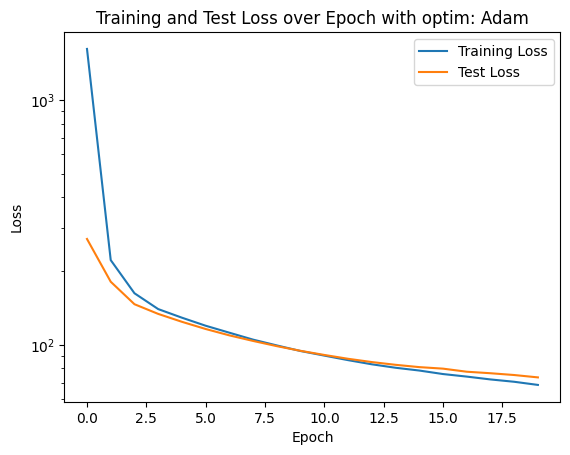

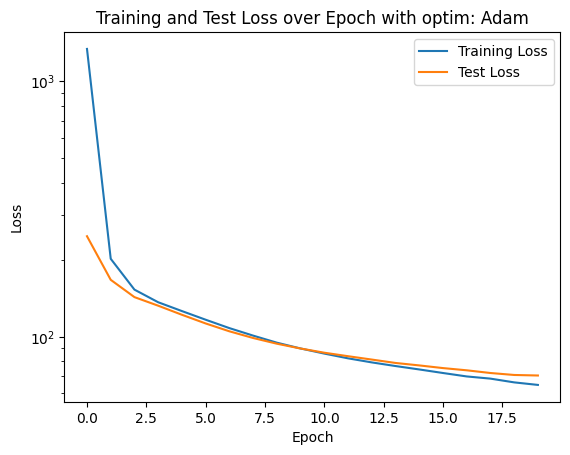

In [29]:
hidden_size = [70,100,128,150]
for hs in hidden_size:
    cinn = RealNVP(input_size=64, hidden_size=hs, blocks=5, condition_size=10)
    cinn = cinn.to(device)
    optim = torch.optim.Adam(cinn.parameters(), lr=0.001)
    train_loss, test_loss = train_inn_cond(model=cinn, train_set=train_dataset_digits, test_set= test_dataset_digits, optim=optim, epochs= 20)
    plt.plot(train_loss, label="Training Loss")
    plt.plot(test_loss, label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.yscale("log")
    plt.title("Training and Test Loss over Epoch with optim: "+str(optim.__class__.__name__) )  
    plt.legend()
    plt.show()

128 best internal width, otherwise the test error starts to get high again

In [32]:
selected_cinn = RealNVP(input_size=64, hidden_size=128, blocks=5, condition_size=10)
selected_cinn = selected_cinn.to(device)
optim = torch.optim.Adam(selected_cinn.parameters(), lr=0.001)
train_loss, test_loss = train_inn_cond(model=selected_cinn, train_set=train_dataset_digits, test_set= test_dataset_digits, optim=optim, epochs= 20)

#### 2D projections of the code space distribution

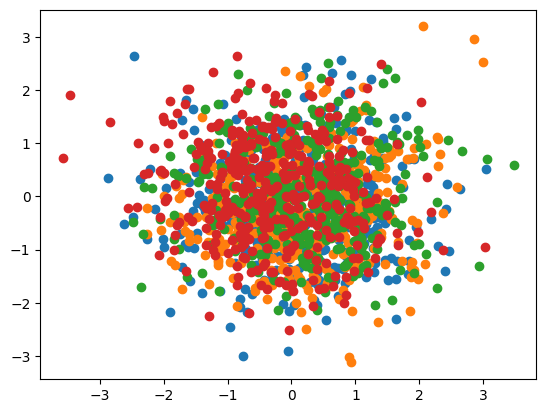

In [36]:
codes = selected_cinn.forward(train_dataset_digits[:400][0],to_onehot(train_dataset_digits[:400][1],10)).detach().cpu().numpy()

plt.scatter(codes[:,0], codes[:,1])
plt.scatter(codes[:,2], codes[:,3])
plt.scatter(codes[:,4], codes[:,5])
plt.scatter(codes[:,6], codes[:,7])
plt.show()

The different projections seem to all be following the normal distribution, we still check analytically as in ex3:

avearge abs mean over all dimensions:  0.15984976


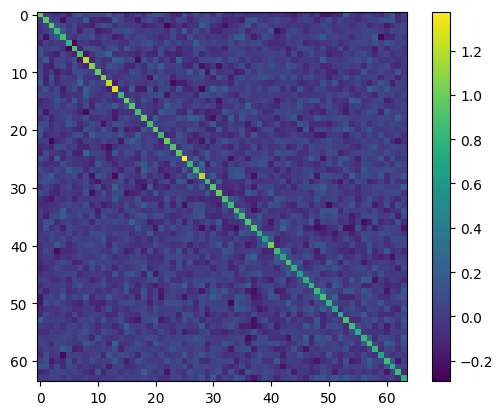

In [40]:
import numpy as np
mean= codes.mean(axis=0)
cov = np.cov(codes, rowvar=False)
print("avearge abs mean over all dimensions: ", abs(mean).mean()) 
im = plt.imshow(cov)
plt.colorbar(im)

we are close to having mean 0 and identity covariance matrix, so we are happy with the results

0


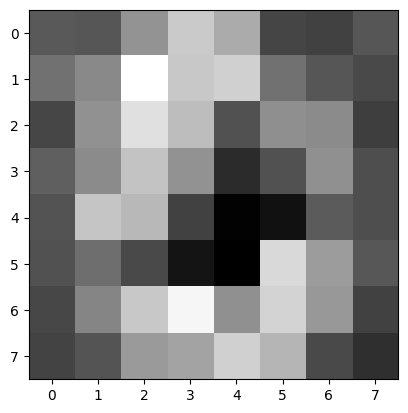

1


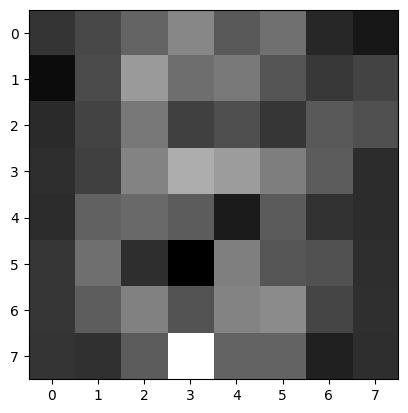

2


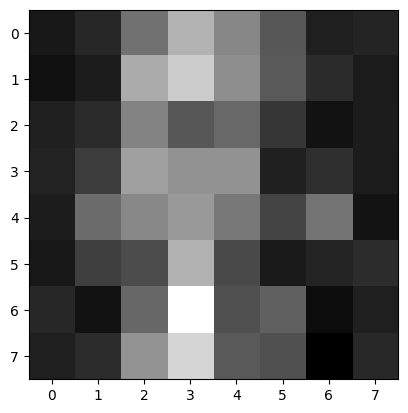

3


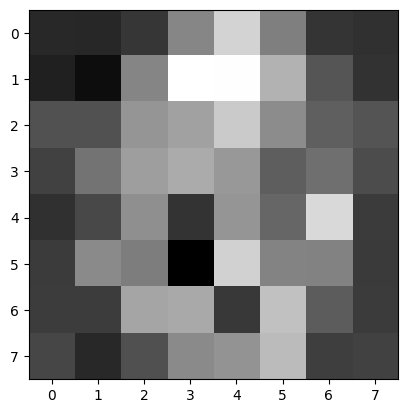

4


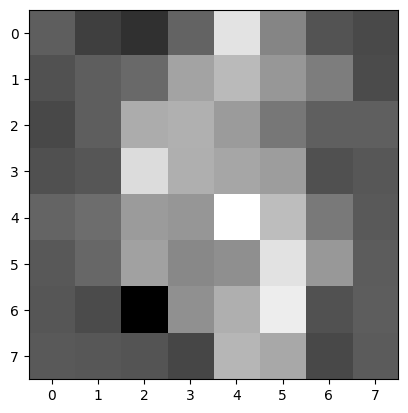

5


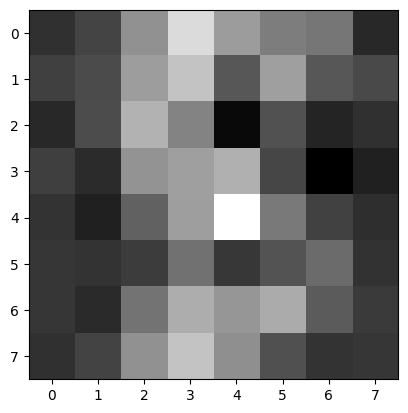

6


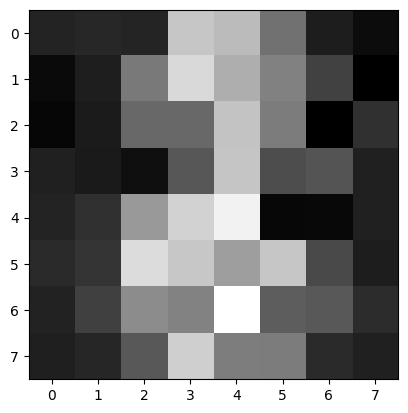

7


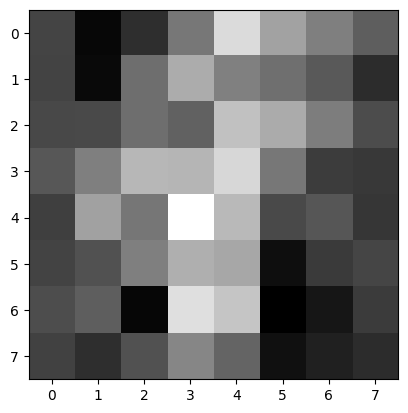

8


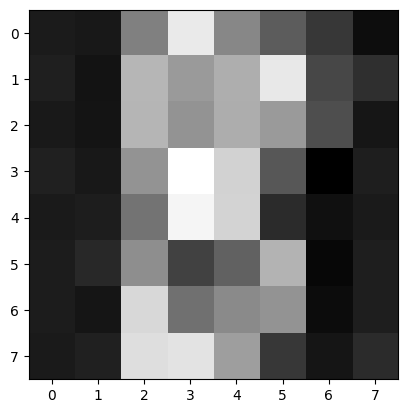

9


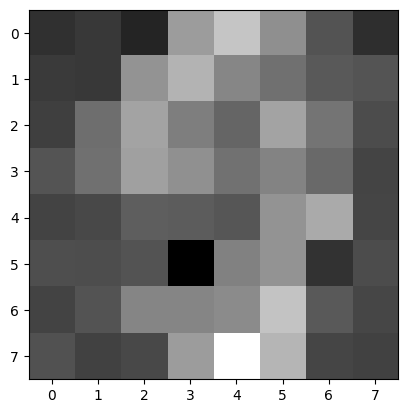

In [37]:
digits = torch.arange(10,device=device)
res = selected_cinn.sample(1,digits).reshape(-1,8,8)
for i in range(len(res)):
    print(i)
    plt.imshow(res[i].detach().cpu().numpy(), cmap='gray',interpolation="nearest")
    plt.show()


we now introduce artificial bottleneck, where we adapt what we did in exercise 3 to work also for conditional INN. 

In [51]:
mse_loss = nn.MSELoss()
def calculate_loss_reconstruction_conditioned(model, codes, x, reconstruction, y, lambda_val = 1.0):
    loss = 0
    for block in model.blocks:
        loss -= block.block_det
    loss += codes.pow(2).sum() / 2
    normal_loss = loss / codes.size(0)
    reconstruction_loss = mse_loss(x, reconstruction)
    total_loss = normal_loss + lambda_val * reconstruction_loss
    return total_loss


def train_cinn_reconstruction(model:RealNVP, train_set, test_set, optim,
                             epochs, batch_size=128, k=4):
    k_mask = torch.zeros((1, model.input_size), device=device)
    k_mask[:, :k] = 1
    scaler = GradScaler("cuda", enabled=(device.type == 'cuda'))
    train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size,
                                               shuffle=True, pin_memory=True)
    test_loader = torch.utils.data.DataLoader(test_set,
                                              batch_size=min(len(test_set), 1000),
                                              shuffle=False, pin_memory=True)

    loss_hist, test_loss_hist = [], []

    for epoch in range(epochs):
        epoch_loss = 0
        for X, Y in train_loader:
            X = X.to(device)
            Y = Y.to(device)
            Y_onehot = to_onehot(Y, model.condition_size).float()

            optim.zero_grad()

            with torch.amp.autocast('cuda', enabled=(device.type=='cuda')):
                codes = model.forward(X, Y_onehot)
                masked_codes = codes * k_mask
                reconstruction = model.reverse(masked_codes, Y_onehot)
                loss = calculate_loss_reconstruction_conditioned(
                    model, codes, X, reconstruction, Y_onehot, lambda_val=1.0
                )

            scaler.scale(loss).backward()
            scaler.step(optim)
            scaler.update()

            epoch_loss += loss.item()

        loss_hist.append(epoch_loss / len(train_loader))

        test_loss = 0
        with torch.no_grad():
            for X, Y in test_loader:
                X = X.to(device)
                Y = Y.to(device)
                Y_onehot = to_onehot(Y, model.condition_size).float()

                codes = model.forward(X, Y_onehot)
                masked_codes = codes * k_mask
                reconstruction = model.reverse(masked_codes, Y_onehot)

                test_loss += calculate_loss_reconstruction_conditioned(
                    model, codes, X, reconstruction, Y_onehot
                ).item()

        test_loss_hist.append(test_loss / len(test_loader))
        print(f"Epoch {epoch+1}/{epochs}: loss={loss_hist[-1]:.4f}")

    return loss_hist, test_loss_hist

### k = 2

In [55]:
bottleneck_cinn_k2 = RealNVP(input_size=64, hidden_size=124, blocks=5, condition_size=10)
bottleneck_cinn_k2 = bottleneck_cinn_k2.to(device)
learning_rate = 1e-3
optim = torch.optim.Adam(bottleneck_cinn_k2.parameters(), lr=learning_rate)
train_loss_history_bottleneck_digits , test_loss_history_bottleneck_digits = [],[]

Using optim:  Adam
Epoch 1/20: loss=788.5226
Epoch 2/20: loss=204.6892
Epoch 3/20: loss=164.2271
Epoch 4/20: loss=140.8937
Epoch 5/20: loss=126.5339
Epoch 6/20: loss=116.2860
Epoch 7/20: loss=107.8603
Epoch 8/20: loss=101.0042
Epoch 9/20: loss=95.5024
Epoch 10/20: loss=90.7029
Epoch 11/20: loss=86.8514
Epoch 12/20: loss=83.3335
Epoch 13/20: loss=80.2063
Epoch 14/20: loss=77.5254
Epoch 15/20: loss=75.0294
Epoch 16/20: loss=72.9717
Epoch 17/20: loss=71.2229
Epoch 18/20: loss=69.4882
Epoch 19/20: loss=67.9017
Epoch 20/20: loss=65.6750
min(train_loss_history)=65.67498563683552 , min(test_loss_history)=73.39625549316406
torch.argmin(torch.tensor(test_loss_history))=tensor(19)


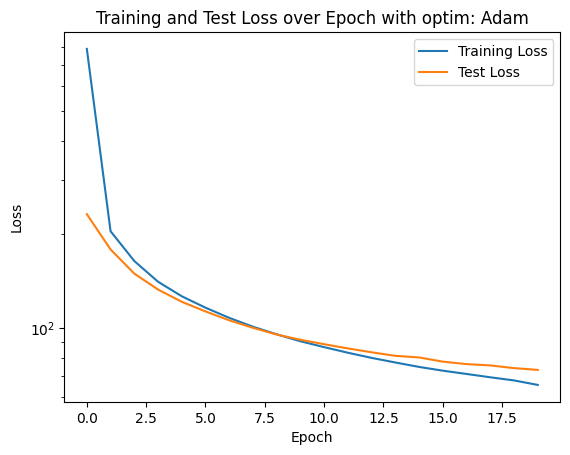

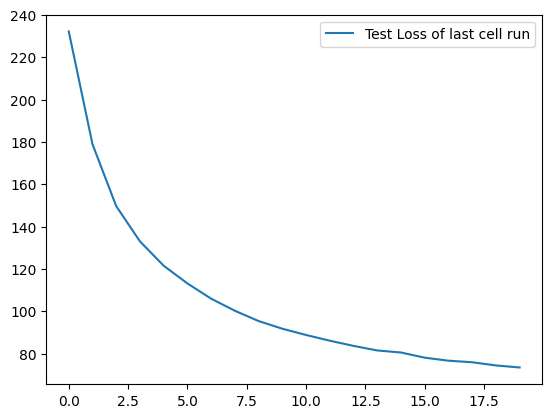

In [56]:
n_epochs = 20
print("Using optim: ", optim.__class__.__name__)
train_loss_history ,test_loss_history = train_cinn_reconstruction(bottleneck_cinn_k2, train_dataset_digits,test_dataset_digits, optim, n_epochs, batch_size=64,k=2)
print(f"{min(train_loss_history)=} , {min(test_loss_history)=}")
print(f"{torch.argmin(torch.tensor(test_loss_history))=}")

train_loss_history_bottleneck_digits.extend(train_loss_history) 
test_loss_history_bottleneck_digits.extend(test_loss_history)
plt.plot(train_loss_history_bottleneck_digits, label="Training Loss")
plt.plot(test_loss_history_bottleneck_digits, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss over Epoch with optim: "+str(optim.__class__.__name__))  
plt.yscale("log")
plt.legend()
plt.show()
plt.plot(test_loss_history,label="Test Loss of last cell run")
plt.legend()
plt.show()

### k=4

Using optim:  Adam
Epoch 1/20: loss=2499.9060
Epoch 2/20: loss=232.7781
Epoch 3/20: loss=180.5490
Epoch 4/20: loss=158.1527
Epoch 5/20: loss=142.9505
Epoch 6/20: loss=132.0236
Epoch 7/20: loss=123.9811
Epoch 8/20: loss=117.1465
Epoch 9/20: loss=111.0991
Epoch 10/20: loss=106.1522
Epoch 11/20: loss=101.4384
Epoch 12/20: loss=97.1972
Epoch 13/20: loss=93.7380
Epoch 14/20: loss=90.7505
Epoch 15/20: loss=87.8865
Epoch 16/20: loss=85.1799
Epoch 17/20: loss=83.0115
Epoch 18/20: loss=81.0421
Epoch 19/20: loss=79.0392
Epoch 20/20: loss=77.1788
min(train_loss_history)=77.17875638215438 , min(test_loss_history)=82.0768814086914
torch.argmin(torch.tensor(test_loss_history))=tensor(19)


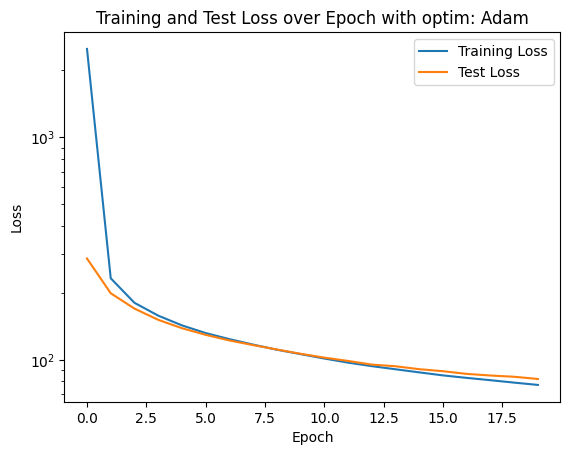

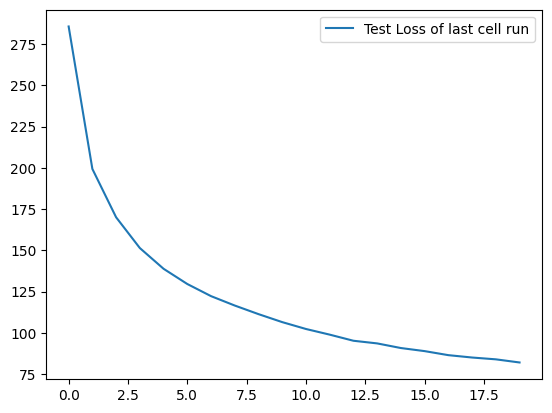

In [57]:
bottleneck_cinn_k4 = RealNVP(input_size=64, hidden_size=124, blocks=5, condition_size=10)
bottleneck_cinn_k4 = bottleneck_cinn_k4.to(device)
learning_rate = 1e-3
optim = torch.optim.Adam(bottleneck_cinn_k4.parameters(), lr=learning_rate)
train_loss_history_bottleneck_digits , test_loss_history_bottleneck_digits = [],[]
n_epochs = 20
print("Using optim: ", optim.__class__.__name__)
train_loss_history ,test_loss_history = train_cinn_reconstruction(bottleneck_cinn_k4, train_dataset_digits,test_dataset_digits, optim, n_epochs, batch_size=64,k=4)
print(f"{min(train_loss_history)=} , {min(test_loss_history)=}")
print(f"{torch.argmin(torch.tensor(test_loss_history))=}")
train_loss_history_bottleneck_digits.extend(train_loss_history) 
test_loss_history_bottleneck_digits.extend(test_loss_history)
plt.plot(train_loss_history_bottleneck_digits, label="Training Loss")
plt.plot(test_loss_history_bottleneck_digits, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss over Epoch with optim: "+str(optim.__class__.__name__))  
plt.yscale("log")
plt.legend()
plt.show()
plt.plot(test_loss_history,label="Test Loss of last cell run")
plt.legend()
plt.show()


### k=8

Using optim:  Adam
Epoch 1/20: loss=1039.8839
Epoch 2/20: loss=193.7387
Epoch 3/20: loss=159.1424
Epoch 4/20: loss=138.6302
Epoch 5/20: loss=124.4960
Epoch 6/20: loss=114.4293
Epoch 7/20: loss=107.0063
Epoch 8/20: loss=100.8396
Epoch 9/20: loss=95.6118
Epoch 10/20: loss=91.1515
Epoch 11/20: loss=87.2733
Epoch 12/20: loss=83.9462
Epoch 13/20: loss=81.2390
Epoch 14/20: loss=78.0649
Epoch 15/20: loss=75.7069
Epoch 16/20: loss=73.6362
Epoch 17/20: loss=71.5586
Epoch 18/20: loss=69.2950
Epoch 19/20: loss=67.1886
Epoch 20/20: loss=65.9864
min(train_loss_history)=65.98641818502675 , min(test_loss_history)=72.9100112915039
torch.argmin(torch.tensor(test_loss_history))=tensor(19)


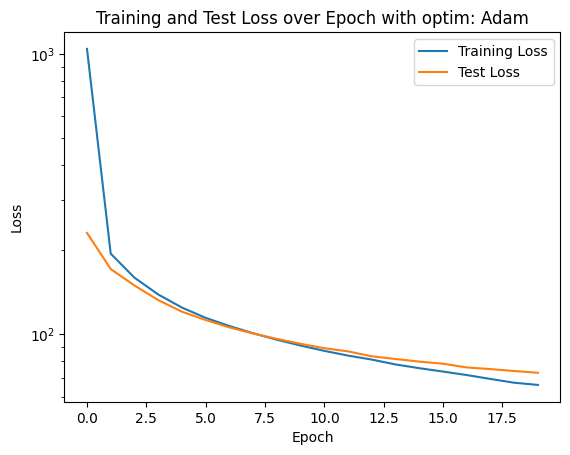

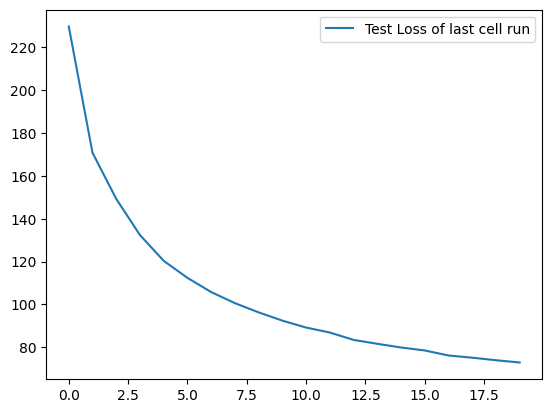

In [58]:
bottleneck_cinn_k8 = RealNVP(input_size=64, hidden_size=124, blocks=5, condition_size=10)
bottleneck_cinn_k8 = bottleneck_cinn_k8.to(device)
learning_rate = 1e-3
optim = torch.optim.Adam(bottleneck_cinn_k8.parameters(), lr=learning_rate)
train_loss_history_bottleneck_digits , test_loss_history_bottleneck_digits = [],[]
n_epochs = 20
print("Using optim: ", optim.__class__.__name__)
train_loss_history ,test_loss_history = train_cinn_reconstruction(bottleneck_cinn_k8, train_dataset_digits,test_dataset_digits, optim, n_epochs, batch_size=64,k=8)
print(f"{min(train_loss_history)=} , {min(test_loss_history)=}")
print(f"{torch.argmin(torch.tensor(test_loss_history))=}")
train_loss_history_bottleneck_digits.extend(train_loss_history) 
test_loss_history_bottleneck_digits.extend(test_loss_history)
plt.plot(train_loss_history_bottleneck_digits, label="Training Loss")
plt.plot(test_loss_history_bottleneck_digits, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss over Epoch with optim: "+str(optim.__class__.__name__))  
plt.yscale("log")
plt.legend()
plt.show()
plt.plot(test_loss_history,label="Test Loss of last cell run")
plt.legend()
plt.show()

We observe for k=2 and k=8 the results are pretty similar, but for k=4 it got worse. We choose k=8 for inference, and implement the first variant

sample from digit 0


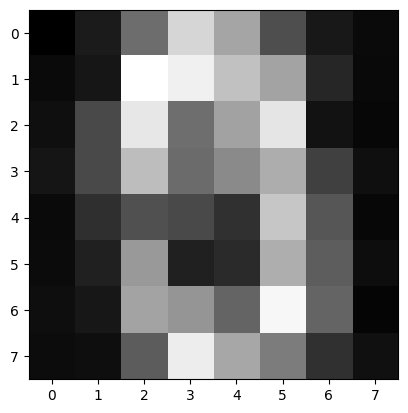

sample from digit 1


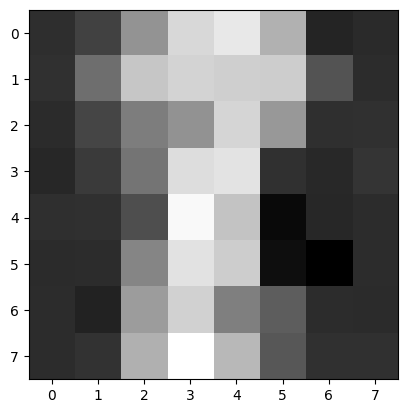

sample from digit 2


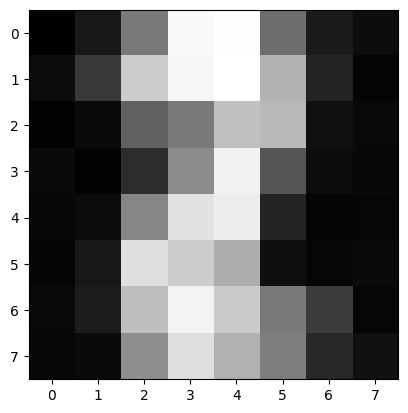

sample from digit 3


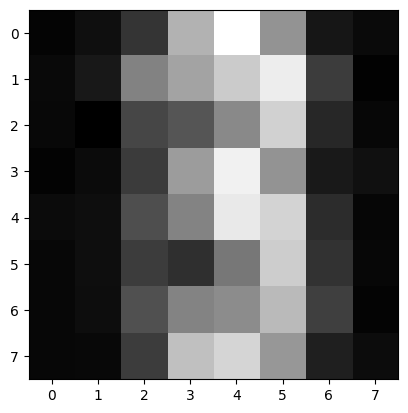

sample from digit 4


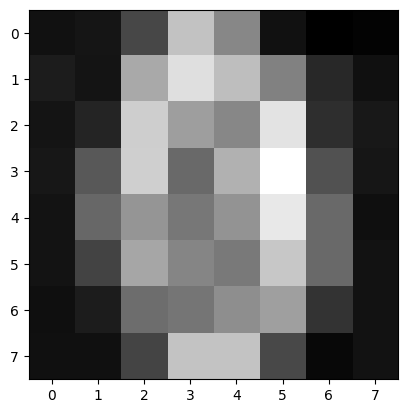

sample from digit 5


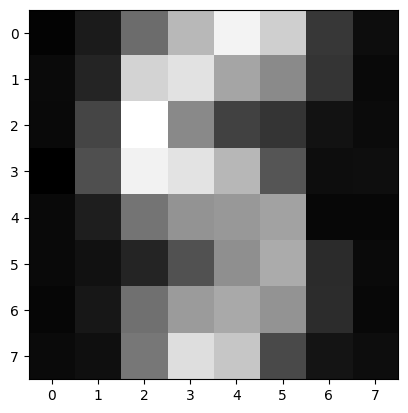

sample from digit 6


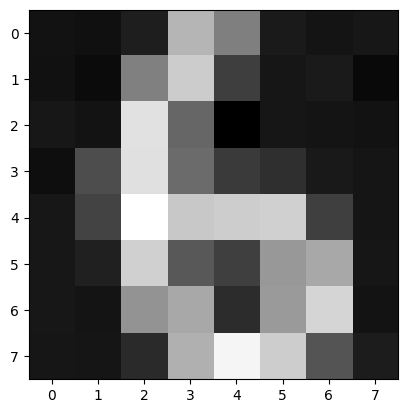

sample from digit 7


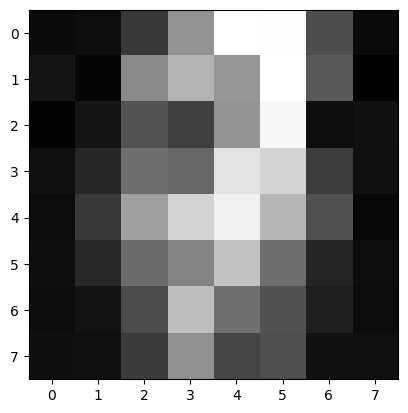

sample from digit 8


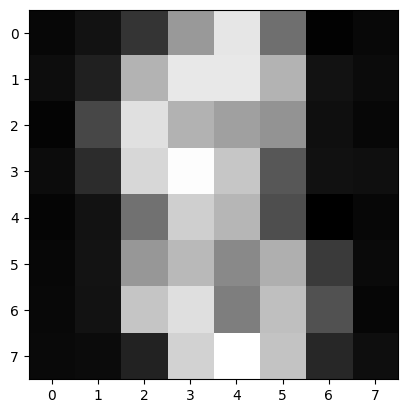

sample from digit 9


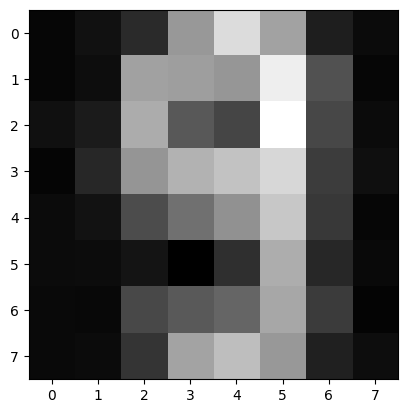

In [74]:
n_classes = 10
n_samples = 1
for i in range(10): 
    print("sample from digit "+str(i))
    #sample digit i
    y = torch.zeros(n_samples, 10, device=device)
    y[:, i] = 1.0       
    #sample latent vector where the last 64-k components are zero
    codes = torch.randn(n_samples, 64, device=device)
    codes[:, 8:] = 0.0

    sampled = bottleneck_cinn_k8.reverse(codes, y)
    sampled_img = sampled.reshape(n_samples, 8, 8)
    for j in range(n_samples):
        plt.imshow(sampled_img[j].detach().cpu().numpy(), cmap='gray',interpolation="nearest")
        plt.show()

we observe much better results than without the artificial bottleneck. Digits are recognisable, so we next will train a random forest classifier to test accuracy and confidence

In [75]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

In [77]:
rf = RandomForestClassifier(
    n_estimators=100,      
    max_depth=None,       
    min_samples_split=2,  
)

classifier = rf.fit(X_train, y_train)
labels_pred = rf.predict(X_test)
acc = accuracy_score(y_test, labels_pred)
print(acc)

0.9638888888888889


the accuracy is good enough that we dont further investigate other parameters. We now turn to computing accuracy and confidence for each digit of our selectedk8 cinn.

In [87]:
def generate_samples(model, digit, n_samples):
    y = torch.zeros(n_samples, 10, device=device)
    y[:, digit] = 1.0

    # latent codes
    codes = torch.randn(n_samples, 64)
    codes[:,8:] = 0.0

    # decode
    imgs = model.reverse(codes, y).detach().cpu().numpy()
    return imgs.reshape(n_samples, 64)


def evaluate_digits(rf_model, cinn_model, n_samples=200):
    results = {}

    for digit in range(10):
        X = generate_samples(cinn_model, digit, n_samples)

        probs = rf_model.predict_proba(X)
        preds = probs.argmax(axis=1)

        accuracy = (preds == digit).mean() * 100.0

        # confidence = prob assigned to correct class
        confidence = probs[:, digit].mean() * 100.0

        results[digit] = (accuracy, confidence)

    return results




In [88]:
results = evaluate_digits(rf, bottleneck_cinn_k8,10000)
for digit, (acc, conf) in results.items():
     print(f"Digit {digit}: Accuracy = {acc:.2f}%, Confidence = {conf:.2f}%")

Digit 0: Accuracy = 34.03%, Confidence = 21.85%
Digit 1: Accuracy = 11.39%, Confidence = 14.17%
Digit 2: Accuracy = 74.48%, Confidence = 45.79%
Digit 3: Accuracy = 69.72%, Confidence = 44.72%
Digit 4: Accuracy = 64.07%, Confidence = 35.83%
Digit 5: Accuracy = 56.27%, Confidence = 32.78%
Digit 6: Accuracy = 67.05%, Confidence = 43.23%
Digit 7: Accuracy = 63.77%, Confidence = 36.09%
Digit 8: Accuracy = 78.65%, Confidence = 46.74%
Digit 9: Accuracy = 55.67%, Confidence = 38.59%


the model is relatively good at generating digits 8 and 2 but not good at all in for example digit 1